In [264]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


In [165]:
P_opt = 100e-3
beam_waist = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,beam_waist)
w_tw_r = omega_tweezer_r(U,beam_waist,m)
w_tw_a = omega_tweezer_a(U,beam_waist,tweezer_wavelength,m)
print(w_tw_r*1e-3/(2*pi),w_tw_a*1e-3/(2*pi))

319.3490592467196 38.23951742236945


# TEST
## brute force calculation of every single ion coupling to every single mode -- radial only

In [388]:
def tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
    qubit_lambda=729e-9,
):
    """
    As before, but compute k = 2*pi/qubit_lambda and scale eigenvectors by
    k * sqrt(hbar / (2 * m * omega_mode)), where omega_mode = 2*pi*freq_Hz.
    """

    if np.isscalar(N_list):
        N_list = [int(N_list)]
    if np.isscalar(P_opt):
        P_opt = [P_opt]

    pi = np.pi
    rows = []
    # compute k from provided qubit wavelength and base scale
    k = 2 * pi / qubit_lambda
    eigvec_scale = k * np.sqrt(hbar / (2 * m))

    for N in N_list:
        # Generate all possible tweezer combinations, but only over the first N/2 ions
        half_range = N // 2
        max_tweezed_local = min(max_tweezed, half_range)
        all_positions = range(half_range)
        all_combos = []
        for r in range(0, max_tweezed_local + 1):
            all_combos.extend(itertools.combinations(all_positions, r))

        w_rf_r = f_rf_r * 2 * pi
        w_rf_r_list = np.full(N, w_rf_r)
        ueq = ion_spacing(N, f_rf_a)[0]

        for P_total in P_opt:
            for tweezed_positions in all_combos:
                n_tweezed = len(tweezed_positions)
                P_per = P_total / n_tweezed if n_tweezed > 0 else 0.0

                pot = potential(omega_tweezer, linewidths, omega_res, P_per, w0)
                w_tw_r = omega_tweezer_r(pot, w0, m)

                combo = np.array([
                    np.sqrt(w_tw_r**2 + w_rf_r_list[i]**2) if i in tweezed_positions else w_rf_r_list[i]
                    for i in range(N)
                ])

                modes = mode_calc_r(m, combo, ueq, N)

                freqs = np.array([f for f, v in modes], dtype=float) if len(modes) else np.array([], dtype=float)
                if len(modes):
                    eigvecs = np.vstack([np.ravel(v) for f, v in modes])
                else:
                    eigvecs = np.empty((0, N))

                row = {
                    "N": N,
                    "Tweezed ions": tweezed_positions,
                    "P_per_tweezer (W)": P_per,
                    "Combined radial frequencies": combo,
                }

                for mode_index in range(N):
                    if mode_index < len(freqs):
                        freq_val = float(freqs[mode_index])  # freq in Hz as returned by mode_calc_r
                        row[f"Mode{mode_index}_freq"] = freq_val
                    else:
                        freq_val = np.nan
                        row[f"Mode{mode_index}_freq"] = np.nan

                    if mode_index < eigvecs.shape[0] and not np.isnan(freq_val) and freq_val > 0:
                        # convert to angular frequency (rad/s)
                        omega_mode = 2.0 * pi * freq_val
                        # final scale uses angular frequency (zero-point amplitude)
                        scale = eigvec_scale * np.sqrt(1.0 / omega_mode)
                        row[f"Mode{mode_index}_eigvec"] = np.ravel(eigvecs[mode_index]).astype(float) * scale
                    else:
                        row[f"Mode{mode_index}_eigvec"] = np.full(N, np.nan, dtype=float)

                rows.append(row)

    return pd.DataFrame(rows)

In [389]:
k = 2*pi/729e-9
0.577*k*np.sqrt(hbar/(2*m*1e6*2*pi))

0.055925501209450425

In [390]:
N = np.arange(3,4)
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3_test= tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3_test)
mode0_list = result["mode_lists"][0]
print(mode0_list)
mode1_list = result["mode_lists"][1]
print(mode1_list)
mode2_list = result["mode_lists"][2]
print(mode2_list)

untweezed = combine_lists(mode0_list, mode1_list, mode2_list)[np.nan]
tweeze0 = combine_lists(mode0_list, mode1_list, mode2_list)[0]
tweeze1 = combine_lists(mode0_list, mode1_list, mode2_list)[1]
tweeze2 = combine_lists(mode0_list, mode1_list, mode2_list)[2]

min_untweezed = condense_by_min_abs(untweezed)
min_tweeze_0 = condense_by_min_abs(tweeze0)
min_tweeze_1 = condense_by_min_abs(tweeze1)
min_tweeze_2 = condense_by_min_abs(tweeze2)

best_untweezed = filter_by_max_min_abs(min_untweezed)
best_tweeze_0 = filter_by_max_min_abs(min_tweeze_0)
best_tweeze_1 = filter_by_max_min_abs(min_tweeze_1)
best_tweeze_2 = filter_by_max_min_abs(min_tweeze_2)
print(best_tweeze_0)
print(best_tweeze_1)
print(best_tweeze_2)
select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2])
print(select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2]))


[(nan, array([0.05595945, 0.05595945, 0.05595945])), (0, array([0.09463037, 0.00205529, 0.00030638]))]
[(nan, array([-6.85843588e-02,  9.29157507e-16,  6.85843588e-02])), (0, array([-0.00140692,  0.05264333,  0.08140127]))]
[(nan, array([ 0.03963641, -0.07927282,  0.03963641])), (0, array([ 0.00159911, -0.08148678,  0.05272627]))]


[(nan, array([0.05595945, 0.05595945, 0.05595945])), (0, array([0.09463037, 0.00205529, 0.00030638]))]
[(nan, array([-6.85843588e-02,  9.29157507e-16,  6.85843588e-02])), (0, array([-0.00140692,  0.05264333,  0.08140127]))]
[(nan, array([ 0.03963641, -0.07927282,  0.03963641])), (0, array([ 0.00159911, -0.08148678,  0.05272627]))]


KeyError: 1

In [391]:
N3_test

,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec
0,3,(),0.0,"[6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.05595945091480255, 0.05595945091480368, 0.055959450914800805]",998591.769782,"[-0.06858435881036137, 9.291575067725432e-16, 0.06858435881036089]",996616.904544,"[0.03963641089674457, -0.07927282179349088, 0.03963641089674782]"
1,3,"(0,)",0.1,"[6595799.989691874, 6283185.307179586, 6283185.307179586]",1.048571e+06,"[0.09463036598319628, 0.0020552895166526903, 0.00030638087549130785]",999458.971232,"[-0.0014069170344167615, 0.0526433290638435, 0.08140126725678516]",996993.358994,"[0.0015991124558238797, -0.08148677623873804, 0.05272626752729103]"


In [392]:
N = np.arange(3,4)
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3)
mode0_list = result["mode_lists"][0]
print(mode0_list)
mode1_list = result["mode_lists"][1]
print(mode1_list)
mode2_list = result["mode_lists"][2]
print(mode2_list)

untweezed = combine_lists(mode0_list, mode1_list, mode2_list)[np.nan]
tweeze0 = combine_lists(mode0_list, mode1_list, mode2_list)[0]
tweeze1 = combine_lists(mode0_list, mode1_list, mode2_list)[1]
tweeze2 = combine_lists(mode0_list, mode1_list, mode2_list)[2]

min_untweezed = condense_by_min_abs(untweezed)
min_tweeze_0 = condense_by_min_abs(tweeze0)
min_tweeze_1 = condense_by_min_abs(tweeze1)
min_tweeze_2 = condense_by_min_abs(tweeze2)

best_untweezed = filter_by_max_min_abs(min_untweezed)
best_tweeze_0 = filter_by_max_min_abs(min_tweeze_0)
best_tweeze_1 = filter_by_max_min_abs(min_tweeze_1)
best_tweeze_2 = filter_by_max_min_abs(min_tweeze_2)
print(best_tweeze_0)
print(best_tweeze_1)
print(best_tweeze_2)
select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2])
print(select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2]))


[(nan, array([0.57735027, 0.57735027, 0.57735027])), (0, array([0.99975899, 0.0217139 , 0.00323688])), (1, array([-0.02254184, -0.99949174, -0.02254184])), (2, array([0.00323688, 0.0217139 , 0.99975899]))]
[(nan, array([-7.07106781e-01,  9.57964156e-15,  7.07106781e-01])), (0, array([-0.01451165,  0.54298991,  0.83961382])), (1, array([ 0.70674738, -0.03187897,  0.70674738])), (2, array([ 0.83961382,  0.54298991, -0.01451165]))]
[(nan, array([ 0.40824829, -0.81649658,  0.40824829])), (0, array([ 0.0164737 , -0.83945844,  0.54317415])), (1, array([-7.07106781e-01, -8.42728068e-15,  7.07106781e-01])), (2, array([ 0.54317415, -0.83945844,  0.0164737 ]))]
[(0, (0, 2, 1), -0.8394584355453292)]
[(1, (1, 2, 0), 0.7067473845002648)]
[(2, (2, 0, 1), -0.8394584355453952)]
[(0, (0, 2, 1), -0.8394584355453292), (2, (2, 0, 1), -0.8394584355453952)]


In [393]:
N3_test.iloc[1]

N                                                                                                 3
Tweezed ions                                                                                   (0,)
P_per_tweezer (W)                                                                               0.1
Combined radial frequencies               [6595799.989691874, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                           1048570.744246
Mode0_eigvec                   [0.09463036598319628, 0.0020552895166526903, 0.00030638087549130785]
Mode1_freq                                                                            999458.971232
Mode1_eigvec                      [-0.0014069170344167615, 0.0526433290638435, 0.08140126725678516]
Mode2_freq                                                                            996993.358994
Mode2_eigvec                     [0.0015991124558238797, -0.08148677623873804, 0.05272626752729103]


In [394]:
N3.iloc[1]

N                                                                                              3
Tweezed ions                                                                                (0,)
P_per_tweezer (W)                                                                            0.1
Combined radial frequencies            [6595799.989691874, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                        1048570.744246
Mode0_eigvec                   [0.9997589855694827, 0.021713898502571154, 0.0032368788823396444]
Mode1_freq                                                                         999458.971232
Mode1_eigvec                     [-0.014511653546580886, 0.5429899093018244, 0.8396138221276139]
Mode2_freq                                                                         996993.358994
Mode2_eigvec                      [0.01647369674429217, -0.8394584355453292, 0.5431741454702771]
Name: 1, dtype: object

In [395]:
# Example usage of tweezer_combos_full_radial_test
N_list = [8]
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

df_test = tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N_list,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
)

print("Result shape:", df_test.shape)
df_test.head()

Result shape: (5, 20)


,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec,Mode3_freq,Mode3_eigvec,Mode4_freq,Mode4_eigvec,Mode5_freq,Mode5_eigvec,Mode6_freq,Mode6_eigvec,Mode7_freq,Mode7_eigvec
0,8,(),0.0,"[6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.03426802525689087, 0.0342680252568963, 0.03426802525689464, 0.03426802525689606, 0.034268025256898156, 0.03426802525689908, 0.03426802525689999, 0.03426802525689907]",998591.769782,"[-0.05388961529269378, -0.036177045236873276, -0.021048244134708256, -0.0069221711763492655, 0.006922171176179658, 0.021048244134549345, 0.03617704523671597, 0.053889615293155245]",996593.061306,"[0.05408848799730353, 0.004126675430238112, -0.02293703244645256, -0.03527813098015428, -0.035278130980462084, -0.02293703244733232, 0.004126675428924745, 0.054088487997939354]",994083.816420,"[-0.040942928081581675, 0.03477633910438397, 0.039787221770829086, 0.016012648373626932, -0.016012648371920735, -0.039787221770300946, -0.03477633910601351, 0.04094292808097735]",991111.053011,"[-0.024418557837900014, 0.05333940164770901, 0.006512804195538366, -0.035433648004630974, -0.03543364800541114, 0.006512804193950973, 0.05333940164750535, -0.02441855783676834]",987703.228989,"[0.011467210007120676, -0.046144724930563714, 0.04020621558049153, 0.02963608078973962, -0.02963608078939955, -0.040206215580748036, 0.04614472492988448, -0.011467210006521619]",983879.058878,"[0.004073956442407397, -0.026407602276693722, 0.054817708530088424, -0.03248406269586113, -0.03248406269571024, 0.05481770853007785, -0.026407602276544602, 0.004073956442238657]",979651.598052,"[-0.0009602784106240745, 0.009307359846314464, -0.033271488221311436, 0.060001790212303834, -0.06000179021238592, 0.03327148822145096, -0.009307359846342709, 0.0009602784105945967]"
1,8,"(0,)",0.1,"[6595799.989691874, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.046738e+06,"[0.09462112536526371, 0.0045314924329350305, 0.0010211383743749236, 0.00036829047289100805, 0.00016817305491069346, 8.780084823546813e-05, 4.9299223168529e-05, 2.8050633450412913e-05]",999689.504027,"[-0.0015063604154197708, 0.01955089971898652, 0.027835115194781865, 0.033174958683227444, 0.037236093724296176, 0.040635361305697566, 0.043710661417057955, 0.046787164419935585]",997580.967239,"[0.0023410037171160587, -0.03632348385695899, -0.041793184059204284, -0.035810094035164344, -0.022459770570208763, -0.00266878723969406, 0.024413247030128715, 0.06289421010091448]",994738.866124,"[-0.0025941095422002828, 0.04883069600596012, 0.03225824569777718, 0.0002953289038343999, -0.029363549276045318, -0.04415972583817727, -0.02876577127158106, 0.04870780245632958]",991426.421305,"[-0.002298514031455127, 0.052444266434907745, -0.0026165486440858977, -0.04041562805199475, -0.0334032108250474, 0.011887085679808364, 0.0554597368789734, -0.027327772266134736]",987802.105362,"[0.0015786818267165192, -0.043377832310480625, 0.042595316892914695, 0.0284947288657726, -0.031484105891235036, -0.04002729286314858, 0.047568841696693176, -0.011988334983064253]",983896.143703,"[-0.0007721167379704478, 0.025409893554870038, -0.05484957249613148, 0.03290932445257592, 0.03237395446885622, -0.055108246102592226, 0.026616841715602368, -0.004115371110428781]",979652.809451,"[0.00023240447726950969, -0.00914345909406019, 0.03323555265097014, -0.06000729538671982, 0.06003436239245297, -0.033294687534921916, 0.0093156440106996, -0.0009609345573858521]"
2,8,"(1,)",0.1,"[6283185.307179586, 6595799.989691874, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.042865e+06,"[0.005310761575249401, 0.09444947375111819, 0.007475181319361738, 0.0017386165652788221, 0.0005943322131280013, 0.0002512

# Parallel optimization, tweezed vs untweezed with defined functions

In [170]:
def run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.
    
    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index)), ...]
    """
    
    # 1. Build eigenvector lists for all configurations
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=max_tweezed
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices and collect all mode lists
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 3. Combine modes across all tweezed ions
    combos = combine_lists(*mode_lists_ordered)
    
    # 4. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 5. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 6. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))

  # 7. Compute best ion/mode indices properly
    augmented = []
    for tweezed_ion, mapping, score in winners:
        # Access the corresponding values from combos
        values = None
        for t, combo_indices, arr in combos[tweezed_ion]:
            if combo_indices == mapping:
                values = arr
                break
        
        if values is None:
            # fallback: use mapping itself (less accurate)
            values = np.array(mapping)
        
        # best ion index = position in vector responsible for min(abs) (i.e., score)
        best_ion_index = int(np.argmin(np.abs(values)))
        best_mode_index = mapping[best_ion_index]

        # ✅ ADD P_opt BACK INTO THE RETURNED STRUCTURE
        augmented.append(
            ((tweezed_ion, mapping, score, P_opt), (best_ion_index, best_mode_index))
        )

    return augmented





import numpy as np
import math

def run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
):
    """
    Run optimal mode selection for the untweezed configuration only.
    
    Returns:
        winners: list of tuples
                 [(None, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build eigenvector lists for the untweezed configuration
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=0
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- FIX SECTION ----
    # remove unusable keys (nan, None, empty tuples)
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v

    mode_lists_dict = cleaned
    # ---- END FIX ----
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices numerically if possible
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        # fallback: sort by string representation
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))
    
    if not mode_indices:
        return []
    
    # 3. Collect lists in canonical order
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    
    # 8. Add placeholder for "none tweezed"
    winners = [(None, combo, val) for _, combo, val in winners]

    #can remove this later but this is just to make sure it all works
    print("Keys:", list(mode_lists_dict.keys()))
    
    return winners




In [513]:
import numpy as np
import math

def run_optimal_mode_selection_tweezed_only_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.
    
    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index)), ...]
    """
    
    # 1. Build Lamb-Dicke parameter lists for all configurations
    df = tweezer_combos_full_radial_test(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=max_tweezed
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {
        k: v for k, v in mode_lists_dict.items()
        if k is not None and not (isinstance(k, float) and math.isnan(k)) and k != ()
    }
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices and collect all mode lists
    mode_indices = sorted(
        mode_lists_dict.keys(),
        key=lambda x: (str(x) if isinstance(x, tuple) else x)
    )
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 3. Combine modes across all tweezed ions
    combos = combine_lists(*mode_lists_ordered)
    
    # 4. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 5. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 6. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))

    # 7. Compute best ion/mode indices properly
    augmented = []
    for tweezed_ion, mapping, score in winners:
        # Access the corresponding values from combos
        combo_dict = {combo_indices: arr for _, combo_indices, arr in combos[tweezed_ion]}
        values = combo_dict.get(mapping, np.array(mapping))  # Fallback to mapping
        
        # worst ion index = position in vector responsible for how long it takes
        worst_ion_index = int(np.argmax(np.abs(values)))
        worst_mode_index = mapping[worst_ion_index]

        #✅ ADD P_opt BACK INTO THE RETURNED STRUCTURE
        augmented.append(
            ((tweezed_ion, mapping, score, P_opt), (worst_ion_index, worst_mode_index))
        )

    return augmented


def run_optimal_mode_selection_untweezed_only_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
):
    """
    Run optimal mode selection for the untweezed configuration only.
    
    Returns:
        winners: list of tuples
                 [(None, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build Lamb-Dicke parameter lists for the untweezed configuration
    df = tweezer_combos_full_radial_test(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=0
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {
        k: v for k, v in mode_lists_dict.items()
        if k is not None and not (isinstance(k, float) and math.isnan(k)) and k != ()
    }
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices numerically if possible
    mode_indices = sorted(
        mode_lists_dict.keys(),
        key=lambda x: (str(x) if isinstance(x, tuple) else x)
    )
    
    if not mode_indices:
        return []
    
    # 3. Collect lists in canonical order
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    
    # 8. Add placeholder for "none tweezed"
    winners = [(None, combo, val) for _, combo, val in winners]

    return winners

DO NOT NAME ANYTHING ELSE RESULTS OR UNTWEEZED RESULTS OR TRY TO RUN THE CODE BLOCK UNDERNEATH THIS AGAIN. BOTH OF THEM TAKE LIKE 20 MINUTES

In [516]:
P_opt = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_test_check = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_test_check.append((Ni, winners))


In [517]:
results

[(2,
  [((0, (0, 1), 0.9999048485013973, [0.1]), (0, 0)),
   ((1, (1, 0), -0.9999048485013973, [0.1]), (0, 1))]),
 (3,
  [((0, (0, 2, 1), -0.8394584355453292, [0.1]), (2, 1)),
   ((2, (2, 0, 1), -0.8394584355453952, [0.1]), (2, 1))]),
 (4,
  [((1, (1, 3, 0, 2), -0.866713219836719, [0.1]), (1, 3)),
   ((2, (2, 0, 3, 1), 0.8667132198365607, [0.1]), (1, 0))]),
 (5,
  [((2, (2, 0, 4, 3, 1), -0.6234865428003095, [0.1]), (3, 3)),
   ((2, (2, 4, 0, 3, 1), -0.6234865428003095, [0.1]), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147861, [0.1]), (3, 4))]),
 (7, [((4, (4, 0, 6, 2, 5, 1, 3), -0.5566105567295869, [0.1]), (3, 2))])]

In [379]:
P_opt = [4e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N = 2
N2_check =  tweezer_combos_full_radial_test(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=1
    )

In [380]:
N2_check

,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec
0,2,(),0.000,"[6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.06853605051379354, 0.06853605051379352]",998591.769782,"[-0.06858435881036112, 0.06858435881036114]"
1,2,"(0,)",0.004,"[6295987.92885945, 6283185.307179586]",1.001554e+06,"[0.09246723332247128, 0.028803034026422387]",999076.780955,"[-0.028838720931348, 0.09258180005045162]"


In [381]:
# (2, [((0, (0, 1), 0.09246723332247128, [0.004]), (0, 0))])
val = [
	N2_check.iloc[1]["Mode0_eigvec"][0],
	N2_check.iloc[1]["Mode1_eigvec"][1],
]
# round each element (round doesn't work on lists)
val_rounded = [round(float(x), 4) for x in val]
val_rounded

[0.0925, 0.0926]

In [218]:
results_test_2_7

[(2, [((0, (0, 1), 0.09246723332247128, [0.004]), (0, 0))]),
 (3, [((0, (0, 2, 1), 0.08231057627777907, [0.004]), (2, 1))]),
 (4, [((1, (1, 3, 0, 2), -0.06746571179335598, [0.004]), (0, 1))]),
 (5, [((1, (1, 4, 0, 3, 2), -0.05980098066509359, [0.004]), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.050953590391116355, [0.004]), (0, 2))]),
 (7,
  [((0, (0, 5, 6, 1, 3, 2, 4), 0.04598095942867622, [0.004]), (1, 5)),
   ((0, (0, 5, 6, 1, 3, 4, 2), 0.04598095942867622, [0.004]), (1, 5))])]

In [219]:
results_test_8

[(8,
  [((2, (2, 0, 7, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 0, 7, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3))])]

In [220]:
results_test_9

[(9,
  [((0, (0, 7, 8, 6, 1, 5, 2, 3, 4), 0.039495295022577384, [0.004]), (5, 5)),
   ((0, (0, 7, 8, 6, 1, 5, 4, 2, 3), 0.039495295022577384, [0.004]), (5, 5))])]

In [213]:
results_test_10

[(10,
  [((4, (4, 0, 9, 7, 1, 3, 8, 2, 6, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 0, 9, 7, 1, 6, 8, 2, 3, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 0, 9, 7, 8, 3, 1, 2, 6, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 0, 9, 7, 8, 6, 1, 2, 3, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 8, 0, 9, 1, 3, 2, 7, 6, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 8, 0, 9, 1, 3, 7, 2, 6, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 8, 0, 9, 1, 6, 2, 7, 3, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 8, 0, 9, 1, 6, 7, 2, 3, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 8, 9, 0, 1, 3, 2, 7, 6, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 8, 9, 0, 1, 3, 7, 2, 6, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 8, 9, 0, 1, 6, 2, 7, 3, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 8, 9, 0, 1, 6, 7, 2, 3, 5), 0.03591312794847569, [0.004]), (0, 4)),
   ((4, (4, 9, 0, 7, 1, 3, 8, 2, 6

In [201]:
#calculating how long N=10 should take
timecheck8 = (8*7*6*5*4*3*2*1 * 4 )/ 21.6
timecheck9 = (98*7*6*5*4*3*2*1 * 4 )/ (8*60+33)
print(timecheck8,timecheck9)

7466.666666666666 3851.2280701754385


In [221]:
results_test = results_test_2_7 + results_test_8 + results_test_9 + results_test_10

In [528]:
results_test

[(2, [((0, (0, 1), 0.09246723332247128, [0.004]), (0, 0))]),
 (3, [((0, (0, 2, 1), 0.08231057627777907, [0.004]), (2, 1))]),
 (4, [((1, (1, 3, 0, 2), -0.06746571179335598, [0.004]), (0, 1))]),
 (5, [((1, (1, 4, 0, 3, 2), -0.05980098066509359, [0.004]), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.050953590391116355, [0.004]), (0, 2))]),
 (7,
  [((0, (0, 5, 6, 1, 3, 2, 4), 0.04598095942867622, [0.004]), (1, 5)),
   ((0, (0, 5, 6, 1, 3, 4, 2), 0.04598095942867622, [0.004]), (1, 5))]),
 (8,
  [((2, (2, 0, 7, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 0, 7, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3))]),
 (9,
  [((0, (0, 7, 8, 6, 1, 5, 2, 3, 4), 0.039495295022577384, [0.004]), (5, 5)),
   ((0, (0, 7, 8, 6, 1, 5, 4, 2, 3), 0.039495295022577384, [0.004]), (5, 5))]),
 (10,
  [((4, (4, 0, 9, 7, 1, 3, 8, 2, 6, 5

In [529]:
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
"""
results = []
for Ni in range(3, 8, 2):
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results.append((Ni, winners))"""

[(2, [((0, (0, 1), 0.09246723332247128, [0.004]), (0, 0))]),
 (3, [((0, (0, 2, 1), 0.08231057627777907, [0.004]), (2, 1))]),
 (4, [((1, (1, 3, 0, 2), -0.06746571179335598, [0.004]), (0, 1))]),
 (5, [((1, (1, 4, 0, 3, 2), -0.05980098066509359, [0.004]), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.050953590391116355, [0.004]), (0, 2))]),
 (7,
  [((0, (0, 5, 6, 1, 3, 2, 4), 0.04598095942867622, [0.004]), (1, 5)),
   ((0, (0, 5, 6, 1, 3, 4, 2), 0.04598095942867622, [0.004]), (1, 5))]),
 (8,
  [((2, (2, 0, 7, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 0, 7, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3))]),
 (9,
  [((0, (0, 7, 8, 6, 1, 5, 2, 3, 4), 0.039495295022577384, [0.004]), (5, 5)),
   ((0, (0, 7, 8, 6, 1, 5, 4, 2, 3), 0.039495295022577384, [0.004]), (5, 5))]),
 (10,
  [((4, (4, 0, 9, 7, 1, 3, 8, 2, 6, 5

In [104]:
Power = [100]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

"""results_high_P = []
for Ni in range(3, 8, 2):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        Power,
        w0,
        max_tweezed=1,
    )
    results_high_P.append((Ni, winners))"""

'results_high_P = []\nfor Ni in range(2, 8):\n    winners = run_optimal_mode_selection_tweezed_only(\n        omega_tweezer,\n        linewidths,\n        omega_res,\n        m,\n        mode_calc_r,\n        Ni,\n        f_rf_r,\n        f_rf_a,\n        Power,\n        w0,\n        max_tweezed=1,\n    )\n    results_high_P.append((Ni, winners))'

In [105]:
untweezed_results = []
for Ni in range(2,11):
    winners = run_optimal_mode_selection_untweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))


Keys: [0, 1]
Keys: [0, 1, 2]
Keys: [0, 1, 2, 3]
Keys: [0, 1, 2, 3, 4]
Keys: [0, 1, 2, 3, 4, 5]
Keys: [0, 1, 2, 3, 4, 5, 6]


In [223]:
results

In [107]:
untweezed_results

[(2, [(None, (0, 1), 0.06853605051379354)]),
 (3, [(None, (0, 2, 1), 0.05595945091480255)]),
 (4,
  [(None, (0, 3, 1, 2), 0.048462306074052594),
   (None, (0, 3, 2, 1), 0.048462306074052594)]),
 (5,
  [(None, (1, 0, 4, 3, 2), 0.04334600429119033),
   (None, (1, 4, 0, 3, 2), 0.04334600429119033)]),
 (6,
  [(None, (3, 0, 5, 1, 4, 2), 0.039569307213333745),
   (None, (3, 0, 5, 4, 1, 2), 0.039569307213333745),
   (None, (3, 5, 0, 1, 4, 2), 0.039569307213333745),
   (None, (3, 5, 0, 4, 1, 2), 0.039569307213333745)]),
 (7,
  [(None, (5, 0, 3, 6, 1, 2, 4), 0.036634059952180054),
   (None, (5, 0, 3, 6, 1, 4, 2), 0.036634059952180054),
   (None, (5, 0, 6, 1, 3, 2, 4), 0.036634059952180054),
   (None, (5, 0, 6, 1, 3, 4, 2), 0.036634059952180054),
   (None, (5, 0, 6, 2, 1, 4, 3), 0.036634059952180054),
   (None, (5, 0, 6, 2, 3, 1, 4), 0.036634059952180054),
   (None, (5, 0, 6, 4, 1, 2, 3), 0.036634059952180054),
   (None, (5, 0, 6, 4, 3, 1, 2), 0.036634059952180054),
   (None, (5, 6, 0, 1, 3, 2, 

In [108]:
# ...existing code...
def sum_inverse_zero_point(df, m, k):
    """
    Use only the first row of df. Return a single scalar:
    (k * (hbar / (2 * m * omega_mode))**0.5) ** -1
    mode frequencies in df are Hz in columns 'Mode0_freq', 'Mode1_freq', ...
    """
    import numpy as np
    from scipy import constants

    hbar = constants.hbar

    # collect mode frequency columns
    freq_cols = [c for c in df.columns if str(c).startswith("Mode") and str(c).endswith("_freq")]
    # sort by mode index if possible
    def _idx(col):
        import re
        mobj = re.match(r"Mode(\d+)_freq", col)
        return int(mobj.group(1)) if mobj else float('inf')
    freq_cols = sorted(freq_cols, key=_idx)

    if not freq_cols or df is None or df.empty:
        return 0.0

    # take first row only
    first = df.iloc[0]
    freqs = first[freq_cols].astype(float).to_numpy()  # frequencies in Hz
    omega = 2.0 * np.pi * freqs  # convert to angular frequency (rad/s)

    # compute (k * sqrt(hbar/(2*m*omega)))^-1 safely, ignoring NaNs/nonpositive omegas
    with np.errstate(divide='ignore', invalid='ignore'):
        valid = np.isfinite(omega) & (omega > 0)
        terms = np.zeros_like(omega, dtype=float)
        terms[valid] = 1.0 / (k * np.sqrt(hbar / (2.0 * m * omega[valid])))
        total = float(np.nansum(terms))

    return total
# ...existing code...

# ...existing code...
df_test = tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
s = sum_inverse_zero_point(df_test, m, k=2*pi/729e-9)
print(s)

30.927156576364787


In [109]:
import numpy as np
import matplotlib.pyplot as plt

def _extract_score_from_win(win):
    """Return numeric score from a winner entry or None if not found."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from a winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]

# Tweezed winners only
x_tweezed = []
y_tweezed = []

for N_val, winners in results_test:
    if not winners:
        continue
    for win in winners:
        tweezed_ion = _extract_tweezed_ion(win)
        if tweezed_ion is None:
            continue   # skip untweezed
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)

# Calculate the ratio (1/y_tweezed) / (1/y_untweezed) = y_untweezed / y_tweezed per N
Ns = np.unique(np.concatenate((x_tweezed, x_untweezed)))
ratios = []

for N in Ns:
    tweezed_scores = y_tweezed[x_tweezed == N]
    untweezed_scores = y_untweezed[x_untweezed == N]
    if len(tweezed_scores) == 0 or len(untweezed_scores) == 0:  # Avoid division by zero
        continue
    # Compute the ratio for each untweezed score to each tweezed score
    for tweezed_score in tweezed_scores:
        for untweezed_score in untweezed_scores:
            ratios.append((N, untweezed_score / tweezed_score))

# Separate the ratios into x and y for plotting
x_ratios = np.array([r[0] for r in ratios])
y_ratios = np.array([r[1] for r in ratios])

# Plot the ratios
plt.figure(figsize=(7, 5))
plt.scatter(x_ratios, y_ratios, color='green')
plt.xlabel('N',fontsize = 14)
plt.ylabel(r'$\tau$ ratio',fontsize = 14)
plt.title(r'$\tau$ Ratio of Tweezed/Untweezed per N',fontsize = 16)
plt.grid(True)
plt.show()

In [435]:
results_test

[(2, [((0, (0, 1), 0.09246723332247128, [0.004]), (0, 0))]),
 (3, [((0, (0, 2, 1), 0.08231057627777907, [0.004]), (2, 1))]),
 (4, [((1, (1, 3, 0, 2), -0.06746571179335598, [0.004]), (0, 1))]),
 (5, [((1, (1, 4, 0, 3, 2), -0.05980098066509359, [0.004]), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.050953590391116355, [0.004]), (0, 2))]),
 (7,
  [((0, (0, 5, 6, 1, 3, 2, 4), 0.04598095942867622, [0.004]), (1, 5)),
   ((0, (0, 5, 6, 1, 3, 4, 2), 0.04598095942867622, [0.004]), (1, 5))]),
 (8,
  [((2, (2, 0, 7, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 0, 7, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 1, 6, 3, 4), -0.04213871147606621, [0.004]), (6, 3)),
   ((2, (2, 7, 0, 5, 6, 1, 3, 4), -0.04213871147606621, [0.004]), (6, 3))]),
 (9,
  [((0, (0, 7, 8, 6, 1, 5, 2, 3, 4), 0.039495295022577384, [0.004]), (5, 5)),
   ((0, (0, 7, 8, 6, 1, 5, 4, 2, 3), 0.039495295022577384, [0.004]), (5, 5))]),
 (10,
  [((4, (4, 0, 9, 7, 1, 3, 8, 2, 6, 5

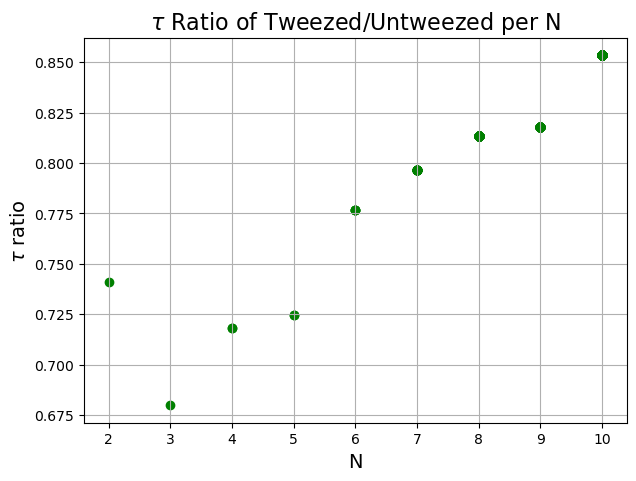

In [236]:

plt.figure(figsize=(7,5))
if y_tweezed.size:
    plt.scatter(x_tweezed, 1.0 / y_tweezed, color='green', label='Tweezed')
if y_untweezed.size:
    plt.scatter(x_untweezed, 1.0 / y_untweezed, color='gray', label='Untweezed', alpha=0.7)
plt.scatter(Ns_scan, y_sum, color='red',  label='Global')

plt.xlabel("N",fontsize = 12)
plt.ylabel(r"$\tau$",fontsize = 12)
plt.title("Parallel Optimization",fontsize = 14)
plt.grid(True)
plt.legend()
plt.show()

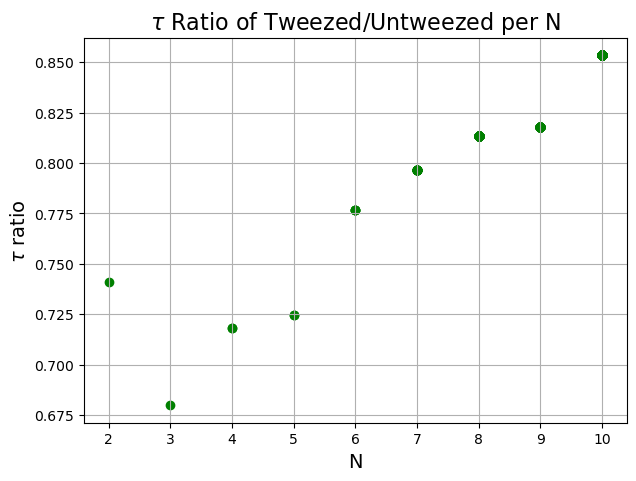

In [530]:
# ...existing code...
plt.figure(figsize=(7,5))

# Tweezed points + labels
if y_tweezed.size:
    ys_t = 1.0 / y_tweezed
    plt.scatter(x_tweezed, ys_t, color='green', label='Tweezed', zorder=3)
    for xi, yi in zip(x_tweezed, ys_t):
        plt.annotate(f"{yi:.3g}", xy=(xi, yi), xytext=(4,4), textcoords='offset points',
                     fontsize=8, color='green', zorder=4)

# Untweezed points + labels
if y_untweezed.size:
    ys_u = 1.0 / y_untweezed
    plt.scatter(x_untweezed, ys_u, color='gray', label='Untweezed', alpha=0.7, zorder=2)
    for xi, yi in zip(x_untweezed, ys_u):
        plt.annotate(f"{yi:.3g}", xy=(xi, yi), xytext=(4,4), textcoords='offset points',
                     fontsize=8, color='gray', alpha=0.85)

# Global points + labels
plt.scatter(Ns_scan, y_sum, color='red', label='Global', zorder=4)
for xi, yi in zip(Ns_scan, y_sum):
    plt.annotate(f"{yi:.3g}", xy=(xi, yi), xytext=(4,-10), textcoords='offset points',
                 fontsize=8, color='red')

plt.xlabel("N", fontsize=12)
plt.ylabel(r"$\tau$", fontsize=12)
plt.title("Parallel Optimization", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# ...existing code...

In [531]:
y_ratios

array([0.74119283, 0.67985736, 0.71832498, ..., 0.85345542, 0.85345542,
       0.85345542])

In [534]:
# remove duplicates from y_ratios preserving original order
y_ratios_unique_P_4_mW = np.array(list(dict.fromkeys(y_ratios.tolist())))
print(y_ratios_unique_P_4_mW)

[0.74119283 0.67985736 0.71832498 0.72483768 0.77657545 0.79672239
 0.81321958 0.81802665 0.85345542]


In [449]:
print(y_untweezed[0])
print(x_untweezed[0])

0.06853605051379354
2.0


In [494]:
y_ref_2 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 2])
y_ref_3 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 3])
y_ref_4 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 4])
y_ref_5 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 5])
y_ref_6 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 6])
y_ref_7 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 7])
y_ref_8 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 8])
y_ref_9 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 9])
y_ref_10 = np.array([1.0 / y_untweezed[i] for i in range(len(x_untweezed)) if x_untweezed[i] == 10])


In [342]:
def run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
):
    """
    Sweep over a list of powers and run optimal mode selection
    for tweezed configurations only using run_optimal_mode_selection_tweezed_only.

    Returns:
        power_results: list of tuples [(P_opt, winners), ...]
    """
    power_results = []

    for P_opt in P_list:
        winners = run_optimal_mode_selection_tweezed_only_test(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            f_rf_a,
            P_opt,
            w0,
            max_tweezed=max_tweezed
        )
        power_results.append((P_opt, winners))

    return power_results


In [403]:
P_opt = [0]
N = 5
N5= tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1,
)
print(N5)

   N Tweezed ions  P_per_tweezer (W)                                                                      Combined radial frequencies  Mode0_freq                                                                                            Mode0_eigvec     Mode1_freq                                                                                                     Mode1_eigvec     Mode2_freq                                                                                                    Mode2_eigvec    Mode3_freq                                                                                                       Mode3_eigvec     Mode4_freq                                                                                                   Mode4_eigvec
0  5           ()                0.0  [6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]   1000000.0  [0.04334600429119, 0.04334600429119033, 0.0433460042911855, 0.04334600429118624, 0.0433460042

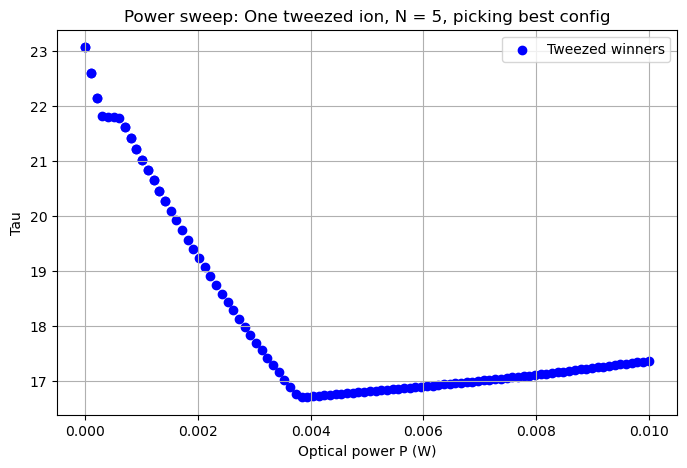

In [344]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 5
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(1e-6, 0.01, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_5 = run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_5:
    if not winners:
        continue
    # winners is a list of tuples: [((tweezed_ion, mapping, val, P_opt), (best_ion, best_mode)), ...]
    best_val = None  # Track the best (minimum) val for each P_opt
    for winner in winners:
        if len(winner) != 2:
            continue
        outer, inner = winner
        # outer == (tweezed_ion, mapping, val, P_opt)
        if len(outer) != 4:
            continue
        tweezed_ion, mapping, val, _ = outer  # P_opt is already available in the loop
        # inner == (best_ion, best_mode)
        if best_val is None or abs(val) < abs(best_val):
            best_val = val  # Update the best val for this P_opt

    if best_val is not None:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(best_val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8, 5))
plt.scatter(x_tweezed, 1/y_tweezed, marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()

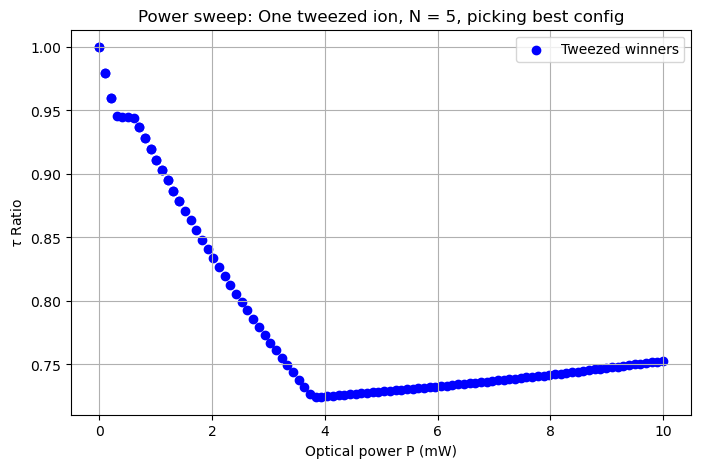

In [423]:
results_power_sweep_5[0]

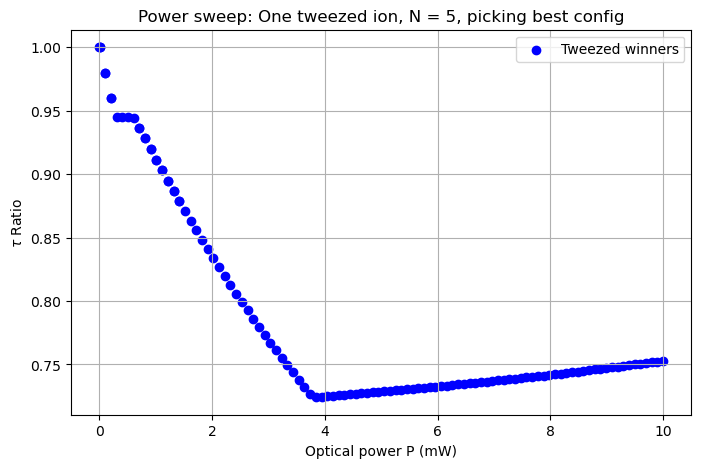

[0.99979983 0.99979983 0.97977342 0.97977342 0.96013275 0.96013275
 0.94533343 0.94498105 0.94463518 0.94429565 0.93669474 0.93669474
 0.92810459 0.92810459 0.91962558 0.91962558 0.91125795 0.91125795
 0.90300192 0.90300192 0.89485764 0.89485764 0.88682523 0.88682523
 0.87890474 0.87890474 0.87109619 0.86339954 0.85581472 0.84834159
 0.84097995 0.83372959 0.82659022 0.81956151 0.81264307 0.80583449
 0.79913528 0.79254493 0.78606287 0.77968849 0.77342114 0.76726011
 0.76120466 0.75525402 0.74940737 0.74366386 0.73802258 0.73248262
 0.72704302 0.72416996 0.72459063 0.72500538 0.72541488 0.72581983
 0.72622087 0.72661864 0.72701377 0.72740685 0.72779846 0.72818916
 0.72857949 0.72896995 0.72936103 0.72975319 0.73014688 0.7305425
 0.73094044 0.73134107 0.73174471 0.73215169 0.7325623  0.73297678
 0.73339539 0.73381834 0.73424583 0.73467802 0.73511506 0.73555707
 0.73600418 0.73645646 0.73691398 0.73737679 0.73784493 0.7383184
 0.73879721 0.73928134 0.73977076 0.74026544 0.74076531 0.741270

In [433]:
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_5[0], marker='o',color = 'blue', label='Tweezed winners')
plt.scatter(0.0,1.00,marker = 'o',color = 'blue')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
#plt.xlim(0,0.5)
#plt.ylim(0.95,1.00)
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [416]:
(1/y_tweezed)/y_ref_5[0]

array([0.99979983, 0.99979983, 0.97977342, 0.97977342, 0.96013275,
       0.96013275, 0.94533343, 0.94498105, 0.94463518, 0.94429565,
       0.93669474, 0.93669474, 0.92810459, 0.92810459, 0.91962558,
       0.91962558, 0.91125795, 0.91125795, 0.90300192, 0.90300192,
       0.89485764, 0.89485764, 0.88682523, 0.88682523, 0.87890474,
       0.87890474, 0.87109619, 0.86339954, 0.85581472, 0.84834159,
       0.84097995, 0.83372959, 0.82659022, 0.81956151, 0.81264307,
       0.80583449, 0.79913528, 0.79254493, 0.78606287, 0.77968849,
       0.77342114, 0.76726011, 0.76120466, 0.75525402, 0.74940737,
       0.74366386, 0.73802258, 0.73248262, 0.72704302, 0.72416996,
       0.72459063, 0.72500538, 0.72541488, 0.72581983, 0.72622087,
       0.72661864, 0.72701377, 0.72740685, 0.72779846, 0.72818916,
       0.72857949, 0.72896995, 0.72936103, 0.72975319, 0.73014688,
       0.7305425 , 0.73094044, 0.73134107, 0.73174471, 0.73215169,
       0.7325623 , 0.73297678, 0.73339539, 0.73381834, 0.73424

In [428]:
# --- prepare power list (don't reuse the name P_opt) ---
P_list = np.linspace(1e-6, 0.1, 2)  # 0.01 .. 1.0 W
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0
results_power_sweep_5_test = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5_test.append((Ni, power_results))
results_power_sweep_5_test

array([0.99979983, 0.99979983, 0.97977342, 0.97977342, 0.96013275,
       0.96013275, 0.94533343, 0.94498105, 0.94463518, 0.94429565,
       0.93669474, 0.93669474, 0.92810459, 0.92810459, 0.91962558,
       0.91962558, 0.91125795, 0.91125795, 0.90300192, 0.90300192,
       0.89485764, 0.89485764, 0.88682523, 0.88682523, 0.87890474,
       0.87890474, 0.87109619, 0.86339954, 0.85581472, 0.84834159,
       0.84097995, 0.83372959, 0.82659022, 0.81956151, 0.81264307,
       0.80583449, 0.79913528, 0.79254493, 0.78606287, 0.77968849,
       0.77342114, 0.76726011, 0.76120466, 0.75525402, 0.74940737,
       0.74366386, 0.73802258, 0.73248262, 0.72704302, 0.72416996,
       0.72459063, 0.72500538, 0.72541488, 0.72581983, 0.72622087,
       0.72661864, 0.72701377, 0.72740685, 0.72779846, 0.72818916,
       0.72857949, 0.72896995, 0.72936103, 0.72975319, 0.73014688,
       0.7305425 , 0.73094044, 0.73134107, 0.73174471, 0.73215169,
       0.7325623 , 0.73297678, 0.73339539, 0.73381834, 0.73424

In [434]:
1 - 0.97977342

0.020226579999999994

In [420]:
x_mW

array([1.000e-03, 1.000e-03, 1.020e-01, 1.020e-01, 2.030e-01, 2.030e-01,
       3.040e-01, 4.050e-01, 5.060e-01, 6.070e-01, 7.080e-01, 7.080e-01,
       8.090e-01, 8.090e-01, 9.100e-01, 9.100e-01, 1.011e+00, 1.011e+00,
       1.112e+00, 1.112e+00, 1.213e+00, 1.213e+00, 1.314e+00, 1.314e+00,
       1.415e+00, 1.415e+00, 1.516e+00, 1.617e+00, 1.718e+00, 1.819e+00,
       1.920e+00, 2.021e+00, 2.122e+00, 2.223e+00, 2.324e+00, 2.425e+00,
       2.526e+00, 2.627e+00, 2.728e+00, 2.829e+00, 2.930e+00, 3.031e+00,
       3.132e+00, 3.233e+00, 3.334e+00, 3.435e+00, 3.536e+00, 3.637e+00,
       3.738e+00, 3.839e+00, 3.940e+00, 4.041e+00, 4.142e+00, 4.243e+00,
       4.344e+00, 4.445e+00, 4.546e+00, 4.647e+00, 4.748e+00, 4.849e+00,
       4.950e+00, 5.051e+00, 5.152e+00, 5.253e+00, 5.354e+00, 5.455e+00,
       5.556e+00, 5.657e+00, 5.758e+00, 5.859e+00, 5.960e+00, 6.061e+00,
       6.162e+00, 6.263e+00, 6.364e+00, 6.465e+00, 6.566e+00, 6.667e+00,
       6.768e+00, 6.869e+00, 6.970e+00, 7.071e+00, 

In [407]:
from collections import defaultdict

data = results_power_sweep_5  # paste data here

occurrences = defaultdict(list)

# --- collect appearances ---
for P_opt, time_series in data:
    for entry in time_series:
        # Unpack the entry structure
        if len(entry) != 2:
            print(f"Unexpected entry structure: {entry}")
            continue
        outer, inner = entry
        if len(outer) != 4:
            print(f"Unexpected outer structure: {outer}")
            continue
        tweezed_ion, perm, score, _ = outer  # P_opt is already available in the loop
        best_ion, best_mode = inner

        # Create a key based on the structure
        key = (tuple(perm), score, (best_ion, best_mode))
        occurrences[key].append(P_opt)


# --- helper: convert timesteps to ranges ---
def make_ranges(times, tol=1e-9):
    times = sorted(times)
    ranges = []

    start = prev = times[0]

    for t in times[1:]:
        # consecutive if timestep spacing unchanged
        if abs(t - prev) <= 0.000101 + tol:
            prev = t
        else:
            ranges.append((start, prev))
            start = prev = t

    ranges.append((start, prev))
    return ranges


# --- keep only duplicates + build ranges ---
ranges_by_key = {}

for key, times in occurrences.items():
    if len(times) > 1:
        ranges_by_key[key] = make_ranges(times)


# --- display ---
for key, ranges in ranges_by_key.items():
    print(key)
    for r in ranges:
        print(f"  {r[0]} → {r[1]}")

[(5,
  [(1e-06,
    [((0, (0, 4, 2, 1, 3), 0.04335468251754514), (0, 0)),
     ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (0, 0))]),
   (0.1, [((1, (1, 4, 0, 2, 3), -0.0587032592877252), (3, 2))])])]

In [383]:
# ...existing code...
first_map = first_appearance_map_nested(results_power_sweep_5)

print(first_map)


ROW: N=5, x=1e-06
Full xb: (1e-06,
 [((0, (0, 4, 2, 1, 3), 0.04335468251754514), (0, 0)),
  ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (0, 0)),
  ((4, (4, 0, 2, 1, 3), 0.043354682517540745), (0, 4)),
  ((4, (4, 0, 2, 3, 1), 0.043354682517540745), (0, 4))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04335468251754514), (0, 0))
    -> First appearance recorded for key=(0, (0, 4, 2, 1, 3)) at x=1e-06
  entry: ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (0, 0))
    -> First appearance recorded for key=(0, (0, 4, 2, 3, 1)) at x=1e-06
  entry: ((4, (4, 0, 2, 1, 3), 0.043354682517540745), (0, 4))
    -> First appearance recorded for key=(4, (4, 0, 2, 1, 3)) at x=1e-06
  entry: ((4, (4, 0, 2, 3, 1), 0.043354682517540745), (0, 4))
    -> First appearance recorded for key=(4, (4, 0, 2, 3, 1)) at x=1e-06

ROW: N=5, x=0.00010200000000000001
Full xb: (0.00010200000000000001,
 [((0, (0, 4, 2, 1, 3), 0.04424084518932712), (0, 0)),
  ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (0, 0)),
  ((4, (4, 0, 2, 1, 3),

In [384]:
first_map = first_appearance_map_nested(results_power_sweep_5)

# Pretty print sorted by x
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"a={a}, perm={perm} -> x={x}")



ROW: N=5, x=1e-06
Full xb: (1e-06,
 [((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1))
    -> First appearance recorded for key=(0, (0, 4, 2, 1, 3)) at x=1e-06
  entry: ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))
    -> First appearance recorded for key=(0, (0, 4, 2, 3, 1)) at x=1e-06

ROW: N=5, x=0.00010200000000000001
Full xb: (0.00010200000000000001,
 [((0, (0, 4, 2, 1, 3), 0.04424084518932712), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04424084518932712), (3, 1))
  entry: ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (3, 3))

ROW: N=5, x=0.00020300000000000003
Full xb: (0.00020300000000000003,
 [((0, (0, 4, 2, 1, 3), 0.045145844906395484), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.045145844906395484), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.045145844906395484), (3, 1))
  entry: ((0, (0, 4, 2, 3, 1), 0.0451

In [385]:
# ...existing code...
plt.figure(figsize=(8,5))
ax = plt.gca()
x_mW = x_tweezed * 1e3
y_ref = y_ref_5[0]
ax.axhline(1.0, linestyle='--', color='gray', linewidth=1)
ax.scatter(x_mW, (1.0 / y_tweezed)/y_ref, marker='o', color='blue', label='Tweezed winners')

# draw vertical dotted lines at first appearance x-values (if available)
first_map = first_appearance_map_nested(results_power_sweep_5)
xs = [float(v) for v in first_map.values() if np.isfinite(v)]
xs_mW = np.array(xs) * 1e3
for xv in xs_mW:
    ax.axvline(x=xv, color='red', linestyle='-', linewidth=1, alpha=0.4)

# place label just underneath the dashed line and a little to the right
xlim = ax.get_xlim()
x_pos = xlim[0] + 0.05 * (xlim[1] - xlim[0])  # small right offset
ylim = ax.get_ylim()
y_offset = 0.01 * (ylim[1] - ylim[0])
ax.text(x_pos, 1.0 - y_offset, f'Untweezed τ = {y_ref:.3g}', color='gray',
        ha='left', va='top', fontsize=12, alpha=0.9)

ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\\tau$")
ax.set_title("N=5, best config per power")
ax.grid(True)
#ax.legend(loc = 'upper right')
plt.show()
# ...existing code...


ROW: N=5, x=1e-06
Full xb: (1e-06,
 [((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1))
    -> First appearance recorded for key=(0, (0, 4, 2, 1, 3)) at x=1e-06
  entry: ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))
    -> First appearance recorded for key=(0, (0, 4, 2, 3, 1)) at x=1e-06

ROW: N=5, x=0.00010200000000000001
Full xb: (0.00010200000000000001,
 [((0, (0, 4, 2, 1, 3), 0.04424084518932712), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04424084518932712), (3, 1))
  entry: ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (3, 3))

ROW: N=5, x=0.00020300000000000003
Full xb: (0.00020300000000000003,
 [((0, (0, 4, 2, 1, 3), 0.045145844906395484), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.045145844906395484), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.045145844906395484), (3, 1))
  entry: ((0, (0, 4, 2, 3, 1), 0.0451


ROW: N=5, x=1e-06
Full xb: (1e-06,
 [((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1))
    -> First appearance recorded for key=(0, (0, 4, 2, 1, 3)) at x=1e-06
  entry: ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))
    -> First appearance recorded for key=(0, (0, 4, 2, 3, 1)) at x=1e-06

ROW: N=5, x=0.00010200000000000001
Full xb: (0.00010200000000000001,
 [((0, (0, 4, 2, 1, 3), 0.04424084518932712), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04424084518932712), (3, 1))
  entry: ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (3, 3))

ROW: N=5, x=0.00020300000000000003
Full xb: (0.00020300000000000003,
 [((0, (0, 4, 2, 1, 3), 0.045145844906395484), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.045145844906395484), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.045145844906395484), (3, 1))
  entry: ((0, (0, 4, 2, 3, 1), 0.0451

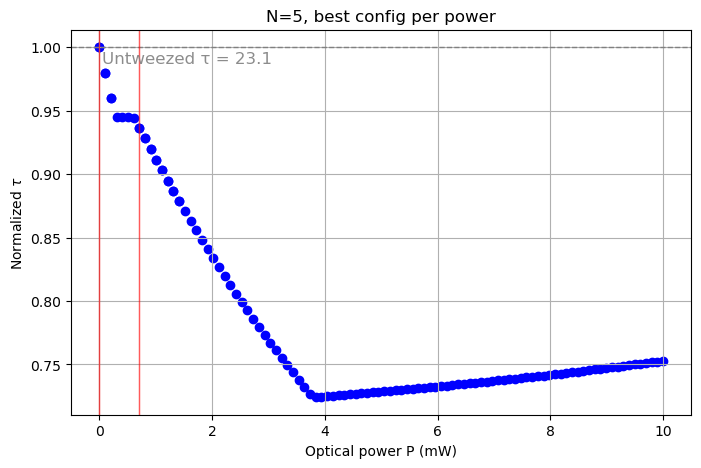

In [354]:
# ...existing code...
plt.figure(figsize=(8,5))
ax = plt.gca()
x_mW = x_tweezed * 1e3
y_ref = 23.0701772
ax.axhline(1.0, linestyle='--', color='gray', linewidth=1)
ax.scatter(x_mW, (1.0 / y_tweezed)/y_ref, marker='o', color='blue', label='Tweezed winners')

# draw vertical dotted lines at first appearance x-values (if available)
first_map = first_appearance_map_nested(results_power_sweep_5)
xs = [float(v) for v in first_map.values() if np.isfinite(v)]
xs_mW = np.array(xs) * 1e3
for xv in xs_mW:
    ax.axvline(x=xv, color='red', linestyle='-', linewidth=1, alpha=0.4)

# add manual vertical red lines (provided values are in W -> convert to mW)
for w in (0.000506
, 0.00708,0.00596

):
    ax.axvline(x=w * 1e3, color='red', linestyle='-', linewidth=1.2, alpha=0.9)

# place label just underneath the dashed line and a little to the right
xlim = ax.get_xlim()
x_pos = xlim[0] + 0.05 * (xlim[1] - xlim[0])  # small right offset
ylim = ax.get_ylim()
y_offset = 0.01 * (ylim[1] - ylim[0])
ax.text(x_pos, 1.0 - y_offset, f'Untweezed τ = {y_ref:.3g}', color='gray',
        ha='left', va='top', fontsize=12, alpha=0.9)

ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\tau$")
ax.set_title("N=5, best config per power")
ax.grid(True)
#ax.legend(loc = 'upper right')
plt.show()
# ...existing code...


ROW: N=5, x=1e-06
Full xb: (1e-06,
 [((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1))
    -> First appearance recorded for key=(0, (0, 4, 2, 1, 3)) at x=1e-06
  entry: ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))
    -> First appearance recorded for key=(0, (0, 4, 2, 3, 1)) at x=1e-06

ROW: N=5, x=0.00010200000000000001
Full xb: (0.00010200000000000001,
 [((0, (0, 4, 2, 1, 3), 0.04424084518932712), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.04424084518932712), (3, 1))
  entry: ((0, (0, 4, 2, 3, 1), 0.04424084518932712), (3, 3))

ROW: N=5, x=0.00020300000000000003
Full xb: (0.00020300000000000003,
 [((0, (0, 4, 2, 1, 3), 0.045145844906395484), (3, 1)),
  ((0, (0, 4, 2, 3, 1), 0.045145844906395484), (3, 3))])
  entry: ((0, (0, 4, 2, 1, 3), 0.045145844906395484), (3, 1))
  entry: ((0, (0, 4, 2, 3, 1), 0.0451

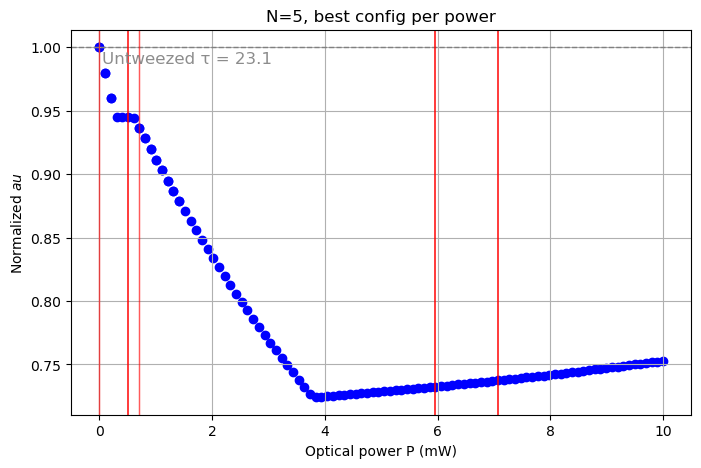

In [372]:
# print positions of red vertical lines (first-appearance x values)
try:
    fm = first_appearance_map(results_power_sweep_5)
except Exception:
    fm = globals().get("first_map", {})

# collect finite x values sorted
xs = sorted([float(v) for v in fm.values() if np.isfinite(v)])
xs_mW = [x * 1e3 for x in xs]

print("first_map (key -> first x in W):")
for k in sorted(fm.keys(), key=lambda kk: float(fm[kk])):
    print(f"{k} -> {fm[k]}")

print("\nRed lines at (W):", xs)
print("Red lines at (mW):", xs_mW)

In [261]:
# checking what the config is for higher power # --- run sweep for desired N values (here only N=5) ---

# --- prepare power list (don't reuse the name P_opt) ---
P_list_test = np.linspace(1e-6, 0.1, 2)  # 0.01 .. 1.0 W
#print(P_list_test)
w0 = 1e-6
f_r = 1e6
f_rf_a = f_r / 3.0
results_power_sweep_5_test = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results_test = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_r,
        f_rf_a,
        P_list_test,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    print(m)
    # store (N, power_results)
    results_power_sweep_5_test.append((Ni, power_results_test))


first_map (key -> first x in W):
(0, (0, 4, 2, 1, 3)) -> 1e-06
(0, (0, 4, 2, 3, 1)) -> 1e-06
(1, (1, 0, 4, 3, 2)) -> 0.0007080000000000002
(1, (1, 4, 0, 3, 2)) -> 0.0007080000000000002

Red lines at (W): [1e-06, 1e-06, 0.0007080000000000002, 0.0007080000000000002]
Red lines at (mW): [0.001, 0.001, 0.7080000000000002, 0.7080000000000002]


In [370]:
# --- prepare power list (don't reuse the name P_opt) ---
P_list = np.linspace(1e-6, 1, 2)  # 0.01 .. 1.0 W
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_5_check = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5_check.append((Ni, power_results))

In [371]:
results_power_sweep_5_check

[(5,
  [(1e-06,
    [((0, (0, 4, 2, 1, 3), 0.04335468251754514), (3, 1)),
     ((0, (0, 4, 2, 3, 1), 0.04335468251754514), (3, 3))]),
   (1.0, [((1, (1, 4, 0, 2, 3), -0.05902445007246621), (2, 0))])])]

In [386]:
test5.loc["Tweezed ions"]

N                                                                                                                                                5
Tweezed ions                                                                                                                                  (2,)
P_per_tweezer (W)                                                                                                                              1.0
Combined radial frequencies                        [6283185.307179586, 6283185.307179586, 8929726.569216797, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                                                                          1417284.396056
Mode0_eigvec                   [-0.0005432996282700573, -0.004980112701343629, -0.9999749029880659, -0.004980112701354534, -0.0005432996282637425]
Mode1_freq                                                                                                            

In [400]:
# access 'Mode2_eigvec' for the third row (index 2)
val = [
	test5.iloc[0]["Mode0_eigvec"][0],
	test5.iloc[0]["Mode1_eigvec"][4],
	test5.iloc[0]["Mode2_eigvec"][2],
	test5.iloc[0]["Mode3_eigvec"][1],
	test5.iloc[0]["Mode4_eigvec"][3],
]
# round each element (round doesn't work on lists)
val_rounded = [round(float(x), 4) for x in val]
val_rounded

[0.4472, 0.6395, 0.5143, -0.6395, 0.4704]

In [402]:
test5

,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec,Mode3_freq,Mode3_eigvec,Mode4_freq,Mode4_eigvec
0,5,(),0.000000,"[6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.04334600429119, 0.04334600429119033, 0.0433460042911855, 0.04334600429118624, 0.043346004291188664]",998591.769784,"[-0.06203018222954044, -0.02925868701700628, -2.615105808331226e-13, 0.029258687016509008, 0.06203018223030257]",996604.410858,"[-0.05220056681378907, 0.027235201841101512, 0.049930729943198957, 0.027235201843212008, -0.05220056681371517]",994120.048940,"[0.029324418454629252, -0.06216953684378651, -1.1257200677864483e-12, 0.06216953684360876, -0.029324418453322343]",991183.598917,"[-0.01017746551532493, 0.04579923173115059, -0.07124353243147753, 0.04579923173045114, -0.010177465514803497]"
1,5,"(0,)",0.000001,"[6283188.511095018, 6283185.307179586, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.04335468251754514, 0.04334719742234898, 0.04334439128946852, 0.04334259133257232, 0.04334114651858909]",998591.978639,"[-0.06203098339115079, -0.029250200981304268, 8.578726075208602e-06, 0.029264427272996912, 0.06203065890438422]",996604.558746,"[-0.052194534627995295, 0.0272416792628559, 0.04993191843405388, 0.02723234668564746, -0.052203557976198474]",994120.095610,"[0.029320843407412957, -0.06217003312621696, 1.5541517265739068e-06, 0.0621703323266683, -0.02932524702961687]",991183.604539,"[-0.010176618853631109, 0.04579899695404755, -0.07124368030370624, 0.04579941219247469, -0.010177518791917896]"
2,5,"(1,)",0.000001,"[6283185.307179586, 6283188.511095018, 6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.04334719748285499, 0.043350043853894016, 0.04334607574287592, 0.04334410105711959, 0.04334259188587376]",998591.816251,"[-0.06202617965923966, -0.029258975538984135, 1.7317759375441703e-06, 0.029261136225238817, 0.06203288966490535]",996604.451122,"[-0.05220394688110711, 0.027236611933858162, 0.04992902201034849, 0.02723329270690487, -0.05219907692452679]",994120.258731,"[0.029325470689226852, -0.06216919899364953, 6.674893104476182e-06, 0.06216856625559897, -0.02932610533849238]",991183.712760,"[-0.010176408956621849, 0.045794790833468164, -0.07124468559224117, 0.045801920923154854, -0.010178277628345465]"


In [401]:
results_test

[0.0433, 0.062, 0.0499, -0.0622, 0.0458]

## Showing the optimal configuration for N=6

In [135]:
print(results[6-2])
#print(results_high_P[6-2])
#print(untweezed_results[6-2])

(6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147861, [0.1]), (3, 4))])


In [136]:
N = 6
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (2,5,0,4,1,3)
tweezed_ions = 2
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 1


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N6 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N6)

[(1255704.4013654306, array([-0.0845683 , -0.2438689 , -0.92793597, -0.24760568, -0.09713705,
       -0.03958305])), (951351.2556375061, array([-0.11404744, -0.08830807, -0.11425732,  0.22505008,  0.50855099,
        0.81047423])), (924088.6109673303, array([-0.91227995, -0.34467261,  0.17387834,  0.03560102, -0.0410669 ,
       -0.1255328 ])), (769055.9334767964, array([-0.07909169,  0.1073797 ,  0.15816996, -0.51771072, -0.61794036,
        0.55436603])), (645392.1744376093, array([ 0.37547283, -0.89317837,  0.20355198,  0.02927549, -0.12614056,
        0.05523262])), (422526.77548757003, array([-0.01874388,  0.06806193, -0.17086626,  0.78606298, -0.57662125,
        0.12423316]))]


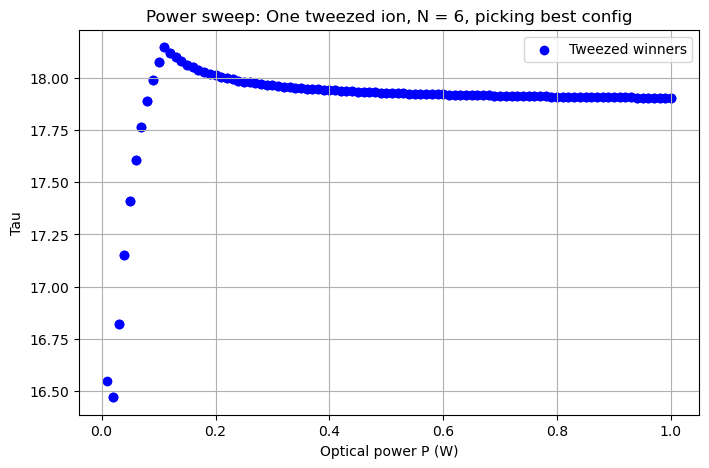

In [137]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 6
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(10e-3, 1, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_6 = run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_6:
    if not winners:
        continue
    for (tweezed_ion, mapping, val), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, 1/y_tweezed, marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config")
plt.grid(True)
plt.legend()
plt.show()


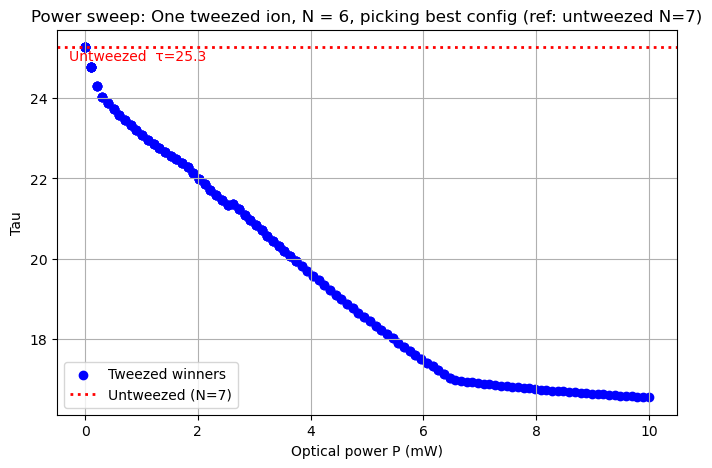

In [138]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 6
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(1e-6, 0.01, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_6 = run_optimal_mode_selection_tweezed_power_sweep_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_6:
    if not winners:
        continue
    for (tweezed_ion, mapping, val), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- find untweezed reference tau from untweezed_results for N=7 ---
unt_ref = np.nan
for N_val, winners in globals().get("untweezed_results", []):
    try:
        if int(N_val) == 6 and winners:
            w = winners[0]
            if ' _extract_score_from_win' in globals():  # fallback if helper not present
                try:
                    ref_score = _extract_score_from_win(w)
                except Exception:
                    ref_score = None
            else:
                # robust extraction similar to other cells
                if isinstance(w, (list, tuple)):
                    if isinstance(w[0], (list, tuple)) and len(w[0]) >= 3:
                        ref_score = w[0][2]
                    elif len(w) >= 3:
                        ref_score = w[2]
                    else:
                        ref_score = None
                else:
                    ref_score = None
            if ref_score is not None:
                ref_score = float(ref_score)
                if ref_score != 0:
                    unt_ref = 1.0 / abs(ref_score)
            break
    except Exception:
        continue

# --- plot (x-axis in mW) ---
plt.figure(figsize=(8,5))
if x_tweezed.size:
    plt.scatter(x_tweezed * 1e3, 1.0 / y_tweezed, marker='o', color='blue', label='Tweezed winners')
if np.isfinite(unt_ref):
    plt.axhline(unt_ref, color='red', linestyle=':', linewidth=2, label='Untweezed (N=7)')
    plt.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.02, 0.95), xycoords='axes fraction',
                 ha='left', va='top', color='red')
plt.xlabel("Optical power P (mW)")
plt.ylabel("Tau")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config (ref: untweezed N=7)")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

In [139]:
results_power_sweep_6

[(1e-06,
  [((0, (0, 5, 2, 1, 4, 3), 0.03957693147581805), (0, 0)),
   ((0, (0, 5, 2, 4, 1, 3), 0.03957693147581805), (0, 0)),
   ((0, (0, 5, 3, 1, 4, 2), 0.03957693147581805), (0, 0)),
   ((0, (0, 5, 3, 4, 1, 2), 0.03957693147581805), (0, 0)),
   ((5, (5, 0, 2, 1, 4, 3), 0.03957693147581852), (0, 5)),
   ((5, (5, 0, 2, 4, 1, 3), 0.03957693147581852), (0, 5)),
   ((5, (5, 0, 3, 1, 4, 2), 0.03957693147581852), (0, 5)),
   ((5, (5, 0, 3, 4, 1, 2), 0.03957693147581852), (0, 5))]),
 (0.00010200000000000001,
  [((0, (0, 5, 2, 1, 4, 3), 0.04035635241389928), (0, 0)),
   ((0, (0, 5, 2, 4, 1, 3), 0.04035635241389928), (0, 0)),
   ((0, (0, 5, 3, 1, 4, 2), 0.04035635241389928), (0, 0)),
   ((0, (0, 5, 3, 4, 1, 2), 0.04035635241389928), (0, 0)),
   ((5, (5, 0, 2, 1, 4, 3), 0.04035635241390715), (0, 5)),
   ((5, (5, 0, 2, 4, 1, 3), 0.04035635241390715), (0, 5)),
   ((5, (5, 0, 3, 1, 4, 2), 0.04035635241390715), (0, 5)),
   ((5, (5, 0, 3, 4, 1, 2), 0.04035635241390715), (0, 5))]),
 (0.0002030000000

In [140]:
def first_appearance_map(data):
    """
    Returns a dict mapping (a, permutation) -> first x-value where it appears.
    Assumes `data` is ordered by increasing x.
    """
    first_x = {}

    for x, entries in data:
        for ((a, permutation, _), _) in entries:
            key = (a, tuple(permutation))
            if key not in first_x:
                first_x[key] = x

    return first_x


In [141]:
# ...existing code...
def first_appearance_map(data):
    """
    Returns a dict mapping (a, permutation) -> first x-value where it appears.
    Assumes `data` is ordered by increasing x.
    """
    first_x = {}

    for x, entries in data:
        for ((a, permutation, _), _) in entries:
            key = (a, tuple(permutation))
            if key not in first_x:
                first_x[key] = x

    return first_x

first_map = first_appearance_map(results_power_sweep_6)

# Pretty-print sorted by x and show full winner rows where each first-appearance occurs
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"\nKey (a={a}, perm={perm}) -> first x = {x}")
    found_block = False
    for p_opt, winners in results_power_sweep_6:
        try:
            match = np.isclose(float(p_opt), float(x))
        except Exception:
            match = (p_opt == x)
        if not match:
            continue
        found_block = True
        print(f"  Matching block: P = {p_opt}, winners_count = {len(winners)}")
        for idx, entry in enumerate(winners):
            print(f"    entry[{idx}]: {entry}")
            # attempt to show the (a, perm) for this entry if present
            try:
                e_a = entry[0][0]
                e_perm = tuple(entry[0][1])
                print(f"      -> entry key = (a={e_a}, perm={e_perm})", end="")
                if (e_a, e_perm) == (a, perm):
                    print("  <-- FIRST APPEARANCE!")
                else:
                    print("")
            except Exception:
                pass
    if not found_block:
        print("  No matching P block found in results_power_sweep_6 for this x")
# ...existing code...


Key (a=0, perm=(0, 5, 2, 1, 4, 3)) -> first x = 1e-06
  Matching block: P = 1e-06, winners_count = 8
    entry[0]: ((0, (0, 5, 2, 1, 4, 3), 0.03957693147581805), (0, 0))
      -> entry key = (a=0, perm=(0, 5, 2, 1, 4, 3))  <-- FIRST APPEARANCE!
    entry[1]: ((0, (0, 5, 2, 4, 1, 3), 0.03957693147581805), (0, 0))
      -> entry key = (a=0, perm=(0, 5, 2, 4, 1, 3))
    entry[2]: ((0, (0, 5, 3, 1, 4, 2), 0.03957693147581805), (0, 0))
      -> entry key = (a=0, perm=(0, 5, 3, 1, 4, 2))
    entry[3]: ((0, (0, 5, 3, 4, 1, 2), 0.03957693147581805), (0, 0))
      -> entry key = (a=0, perm=(0, 5, 3, 4, 1, 2))
    entry[4]: ((5, (5, 0, 2, 1, 4, 3), 0.03957693147581852), (0, 5))
      -> entry key = (a=5, perm=(5, 0, 2, 1, 4, 3))
    entry[5]: ((5, (5, 0, 2, 4, 1, 3), 0.03957693147581852), (0, 5))
      -> entry key = (a=5, perm=(5, 0, 2, 4, 1, 3))
    entry[6]: ((5, (5, 0, 3, 1, 4, 2), 0.03957693147581852), (0, 5))
      -> entry key = (a=5, perm=(5, 0, 3, 1, 4, 2))
    entry[7]: ((5, (5, 0, 3,

In [142]:
first_map = first_appearance_map(results_power_sweep_6)

# Pretty-print sorted by x
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


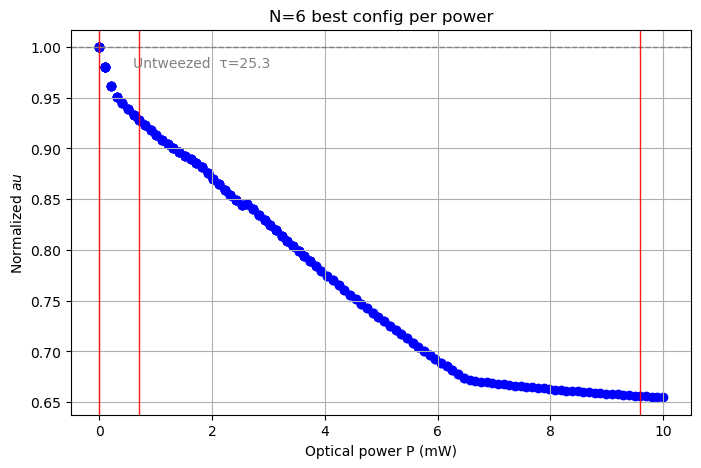

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


In [143]:
#need to add in x=0.0026270000000000004 as a red line and 0.0065660000000000015
y_ref_6 = 25.27211292
fig, ax = plt.subplots(figsize=(8,5))
if x_tweezed.size:
    ax.scatter(x_tweezed * 1e3, (1.0 / y_tweezed)/y_ref_6, marker='o', color='blue', label='Tweezed winners')

    ax.axhline(1, color='gray', linestyle='--', linewidth=1)
    ax.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.1, 0.93), xycoords='axes fraction',
                ha='left', va='top', color='gray')

# draw vertical green lines at first-appearance x positions (mW)
for xv in np.unique(xs_mW):
    ax.axvline(x=xv, color='red', linewidth=1, alpha=0.9)

ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\tau$")
ax.set_title("N=6 best config per power")
ax.grid(True)
#ax.legend()
plt.show()

# Pretty-print sorted by x (uses first_map computed above)
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")
# ...existing code...

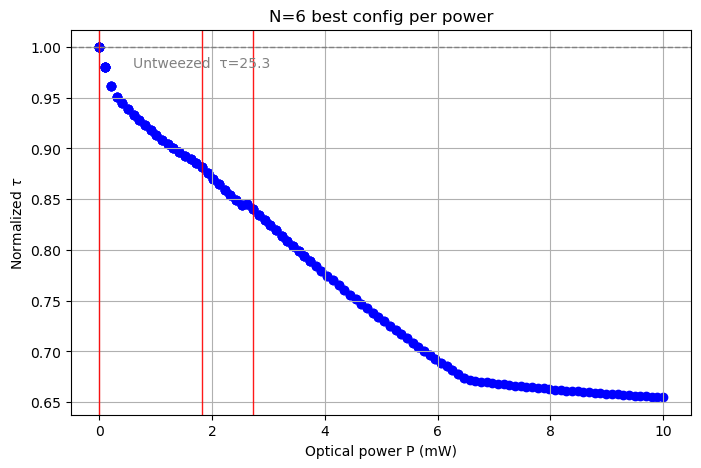

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


In [144]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

y_ref_6 = 25.27211292

# recompute first_map from results to ensure consistency
first_map = first_appearance_map(results_power_sweep_6)

# group keys by their first-appearance x value (in W)
x_to_keys = defaultdict(list)
for (a, perm), x in first_map.items():
    try:
        if np.isfinite(float(x)):
            x_to_keys[float(x)].append((a, tuple(perm)))
    except Exception:
        continue

xs = sorted(x_to_keys.keys())
xs_mW = np.array(xs) * 1e3

fig, ax = plt.subplots(figsize=(8,5))
if x_tweezed.size:
    ax.scatter(x_tweezed * 1e3, (1.0 / y_tweezed)/y_ref_6, marker='o', color='blue', label='Tweezed winners')

ax.axhline(1, color='gray', linestyle='--', linewidth=1)
ax.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.1, 0.93), xycoords='axes fraction',
            ha='left', va='top', color='gray')

# draw vertical green lines at first-appearance x positions (mW) and annotate
for x_w in xs:
    x_mW = x_w * 1e3
    ax.axvline(x=x_mW, color='red', linewidth=1, alpha=0.9)


ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\\tau$")
ax.set_title("N=6 best config per power")
ax.grid(True)
# ax.legend()
plt.show()

# Pretty-print sorted by x (uses first_map computed above)
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")
# ...existing code...

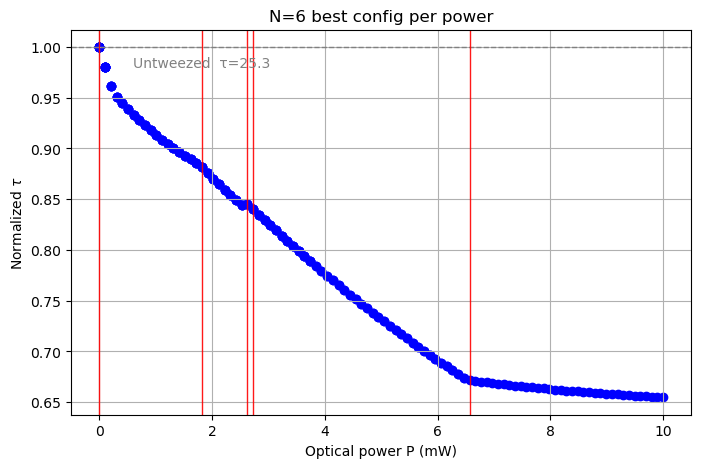

(0, (0, 5, 2, 1, 4, 3)) -> 1e-06
(0, (0, 5, 2, 4, 1, 3)) -> 1e-06
(0, (0, 5, 3, 1, 4, 2)) -> 1e-06
(0, (0, 5, 3, 4, 1, 2)) -> 1e-06
(5, (5, 0, 2, 1, 4, 3)) -> 1e-06
(5, (5, 0, 2, 4, 1, 3)) -> 1e-06
(5, (5, 0, 3, 1, 4, 2)) -> 1e-06
(5, (5, 0, 3, 4, 1, 2)) -> 1e-06
(1, (1, 0, 5, 4, 2, 3)) -> 0.001819
(1, (1, 5, 0, 4, 2, 3)) -> 0.001819
(4, (4, 0, 5, 1, 3, 2)) -> 0.001819
(4, (4, 5, 0, 1, 3, 2)) -> 0.001819
(2, (2, 0, 5, 4, 1, 3)) -> 0.0027280000000000004
(2, (2, 5, 0, 4, 1, 3)) -> 0.0027280000000000004
(3, (3, 0, 5, 1, 4, 2)) -> 0.0027280000000000004
(3, (3, 5, 0, 1, 4, 2)) -> 0.0027280000000000004


In [145]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

y_ref_6 = 25.27211292

# recompute first_map from results to ensure consistency
first_map = first_appearance_map(results_power_sweep_6)

# group keys by their first-appearance x value (in W)
x_to_keys = defaultdict(list)
for (a, perm), x in first_map.items():
    try:
        if np.isfinite(float(x)):
            x_to_keys[float(x)].append((a, tuple(perm)))
    except Exception:
        continue

xs = sorted(x_to_keys.keys())
xs_mW = np.array(xs) * 1e3

fig, ax = plt.subplots(figsize=(8,5))
if x_tweezed.size:
    ax.scatter(x_tweezed * 1e3, (1.0 / y_tweezed)/y_ref_6, marker='o', color='blue', label='Tweezed winners')

ax.axhline(1, color='gray', linestyle='--', linewidth=1)
ax.annotate(f'Untweezed  τ={unt_ref:.3g}', xy=(0.1, 0.93), xycoords='axes fraction',
            ha='left', va='top', color='gray')

# draw vertical red lines at first-appearance x positions (mW)
for x_w in xs:
    x_mW = x_w * 1e3
    ax.axvline(x=x_mW, color='red', linewidth=1, alpha=0.9)

# add the two requested manual red lines (values provided in W -> convert to mW)
for w in (0.0026270000000000004, 0.0065660000000000015):
    ax.axvline(x=w * 1e3, color='red', linestyle='-', linewidth=1, alpha=0.9)

ax.set_xlabel("Optical power P (mW)")
ax.set_ylabel("Normalized $\\tau$")
ax.set_title("N=6 best config per power")
ax.grid(True)
# ax.legend()
plt.show()

# Pretty-print sorted by x (uses first_map computed above)
for (a, perm), x in sorted(first_map.items(), key=lambda item: item[1]):
    print(f"{(a, perm)} -> {x}")
# ...existing code...

# Brute force calculation of 1 ion 1 tweezer for midcurcuit meas type of a setup

In [146]:
from collections import defaultdict

In [147]:
P = 100e-3
N3_result= tweezer_combos_full_radial_test(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P,
    w0,
    max_tweezed=1,
)
result_N3 = build_mode_series_and_combinations(N3_result)
#result_N3
mode0_list = result_N3["mode_lists"][0]
print(mode0_list)
mode1_list = result_N3["mode_lists"][1]
print(mode1_list)
mode2_list = result_N3["mode_lists"][2]
print(mode2_list)

[(nan, array([0.03956931, 0.03956931, 0.03956931, 0.03956931, 0.03956931,
       0.03956931])), (0, array([0.09163396, 0.02642578, 0.0132939 , 0.00778724, 0.0048302 ,
       0.00297431])), (1, array([0.03828041, 0.07623076, 0.03566516, 0.02229049, 0.01503148,
       0.01022903])), (2, array([0.02585026, 0.03898064, 0.0690943 , 0.03798743, 0.02561988,
       0.01782914])), (3, array([0.01782914, 0.02561988, 0.03798743, 0.0690943 , 0.03898064,
       0.02585026])), (4, array([-0.01022903, -0.01503148, -0.02229049, -0.03566516, -0.07623076,
       -0.03828041])), (5, array([-0.00297431, -0.0048302 , -0.00778724, -0.0132939 , -0.02642578,
       -0.09163396]))]
[(nan, array([-0.05897203, -0.03329546, -0.01084095,  0.01084095,  0.03329546,
        0.05897203])), (0, array([ 0.01754972, -0.01664084, -0.03163278, -0.04208123, -0.05071376,
       -0.05891293])), (1, array([-0.02176445, -0.02173048,  0.00929408,  0.03086345,  0.05016752,
        0.07001203])), (2, array([ 0.04076694,  0.0248248

In [265]:

def midcircuit_modes_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     ):
    """
    Compute combined mode lists for all tweezed configurations for given N.
    Returns a DataFrame of best rows (keeps all top-scoring rows, removes lower losers).
    NOTE: Tweezed Ion may equal Coolant Ion (this function allows that).
    """
    results = tweezer_combos_full_radial_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
        max_tweezed=1,
    )
    result = build_mode_series_and_combinations(results)

    mode_list_test = []
    for i in range(len(result) + 1):
        mode_list_test.append(result["mode_lists"][i])

    middle = combine_lists_same_index_df(*mode_list_test)

    # NOTE: we intentionally allow Tweezed Ion == Coolant Ion here (no filtering).

    # collect best per tweezed-ion group (choose canonical one per group)
    best_rows = middle.iloc[0:0].copy()
    tweezed_keys = [k for k in middle["Tweezed Ion"].unique() if pd.notna(k)]
    for key in tweezed_keys:
        subset = middle[middle["Tweezed Ion"] == key]
        if subset.empty:
            continue
        # keep subset as-is (allow coolant == tweezed)
        mn = subset["sum_inverse_middle"].abs().min()
        mask = np.isclose(subset["sum_inverse_middle"].abs(), mn, rtol=1e-12, atol=1e-12)
        tied = subset.loc[mask]
        # pick canonical representative (first by Coolant Ion, NaN last)
        chosen = tied.sort_values("Coolant Ion", na_position="last").iloc[0:1]
        best_rows = pd.concat([best_rows, chosen], ignore_index=True)

    # keep only the globally best score(s) across all tweezed groups
    if best_rows.empty:
        return best_rows

    global_min = best_rows["sum_inverse_middle"].abs().min()
    keep_mask = np.isclose(best_rows["sum_inverse_middle"].abs(), global_min, rtol=1e-8, atol=1e-12)
    final = best_rows.loc[keep_mask].reset_index(drop=True)

    return final

# ...existing code...
# ...existing code...
def midcircuit_modes_untweezed_test(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     ):
    """
    Untweezed version: use combine_lists_same_index_df_untweezed and pick global best(s).
    Ensures:
      - "inverse_mode_couplings" stores 1 / abs(mode_coupling) for each entry
      - "sum_inverse_middle" is the sum of those inverses for the row
    """
    results = tweezer_combos_full_radial_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
        max_tweezed=0,
    )
    result = build_mode_series_and_combinations(results)

    mode_list_test = []
    for i in range(len(result) + 1):
        mode_list_test.append(result["mode_lists"][i])

    # use untweezed combiner that does not expect a 'Tweezed Ion' column
    middle = combine_lists_same_index_df(*mode_list_test)

    if middle.empty:
        return middle

    # Require "Mode couplings" present
    if "Mode couplings" not in middle.columns:
        return middle

    # inverse_mode_couplings = 1 / abs(value) for each entry in Mode couplings
    def inv_abs_list(arr):
        # arr may be list-like or numpy array; try to handle mixed/invalid entries robustly
        try:
            a = np.array([float(x) for x in arr], dtype=float)
        except Exception:
            # fallback: iterate and coerce elementwise (preserve invalid as np.nan)
            out = []
            for x in arr:
                try:
                    out.append(float(x))
                except Exception:
                    out.append(np.nan)
            a = np.array(out, dtype=float)

        a = np.abs(a)
        with np.errstate(divide="ignore", invalid="ignore"):
            inv = np.where(np.isnan(a), np.nan, np.where(a == 0.0, np.inf, 1.0 / a))
        return inv.astype(float)

    # store the actual inverses of the absolute couplings
    middle["inverse_mode_couplings"] = middle["Mode couplings"].apply(inv_abs_list)

    # sum_inverse_middle = sum of those inverses (treat NaN as missing, include np.inf if present)
    middle["sum_inverse_middle"] = middle["inverse_mode_couplings"].apply(lambda arr: float(np.nansum(arr)))

    # select rows with minimal sum_inverse_middle (best candidate(s))
    global_min = middle["sum_inverse_middle"].abs().min()
    keep_mask = np.isclose(middle["sum_inverse_middle"].abs(), global_min, rtol=1e-8, atol=1e-12)
    final = middle.loc[keep_mask].reset_index(drop=True)
    return final

def collect_midcircuit_combined_df_test(
    Ns,
    omega_t,
    linewidths_,
    omega_res_,
    m_,
    mode_calc,
    f_rf_r_,
    f_rf_a_,
    P_,
    w0_,
    return_many_N=False,
):
    """
    Run midcircuit_modes for each N in Ns and return a combined DataFrame.
    Does NOT print or display per-N results. Keeps all rows (no per-N dedupe).
    If return_many_N is True, also return the list of (N, per-N DataFrame).
    """
    dfs = []
    many_N = []

    for N in Ns:
        test_loop = midcircuit_modes_test(
            omega_t,
            linewidths_,
            omega_res_,
            m_,
            mode_calc,
            N,
            f_rf_r_,
            f_rf_a_,
            P_,
            w0_,
        )
        many_N.append((N, test_loop))

        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df["N"] = int(N)
            try:
                df["Tweezed Ion"] = df["Tweezed Ion"].astype(int)
            except Exception:
                pass
            dfs.append(df)

    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True, sort=False)
        cols = [
            "N",
            "Tweezed Ion",
            "Coolant Ion",
            "Mode couplings",
            "inverse_mode_couplings",
            "sum_inverse_middle",
        ]
        combined_df = combined_df[[c for c in cols if c in combined_df.columns]]
    else:
        combined_df = pd.DataFrame()

    if return_many_N:
        return combined_df, many_N
    return combined_df

[(nan, array([0.043346, 0.043346, 0.043346, 0.043346, 0.043346])), (0, array([-0.09269972, -0.02428117, -0.0113824 , -0.00618014, -0.0034344 ])), (1, array([0.03498247, 0.08073967, 0.03364984, 0.01913735, 0.0114781 ]))]
[(nan, array([-6.20301822e-02, -2.92586870e-02, -2.61510581e-13,  2.92586870e-02,
        6.20301822e-02])), (0, array([-0.01669569,  0.02224646,  0.04012735,  0.05314184,  0.06474074])), (1, array([-0.02195628, -0.02036279,  0.01836533,  0.04770558,  0.07677415]))]
[(nan, array([-0.05220057,  0.0272352 ,  0.04993073,  0.0272352 , -0.05220057])), (0, array([ 0.01755744, -0.04920215, -0.04979493, -0.01360074,  0.06346258])), (1, array([-0.08531564,  0.02948941,  0.02299354,  0.00693617, -0.02638785]))]


In [735]:
midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        3,
        f_rf_r,
        f_rf_a,
        1e-3,
        w0,
    )

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,0.0,2,"[-0.04617311333542562, 0.07406399753311392, 0.04229524042947443]","[21.657625569570705, 13.50183669944228, 23.643322270917427]",58.802785


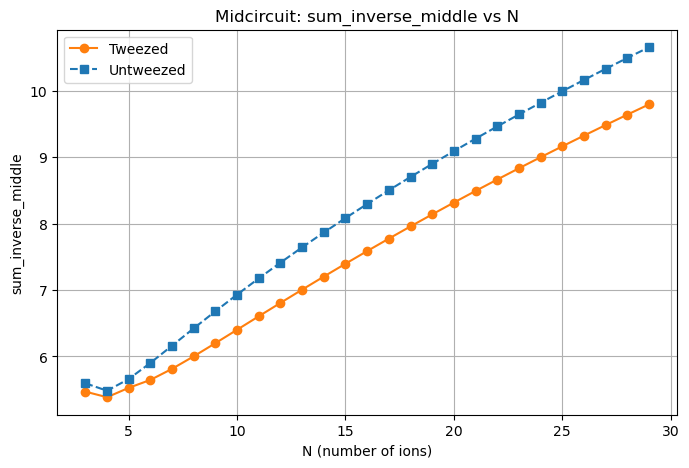

In [266]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

dfs = []
many_N = []

for N in range(3, 30):
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



# ...existing code...
dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 30):
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.plot(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
if Ns_u.size:
    plt.plot(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
plt.xlabel("N (number of ions)")
plt.ylabel("sum_inverse_middle")
plt.title("Midcircuit: sum_inverse_middle vs N")
plt.grid(True)
plt.legend()
plt.show()

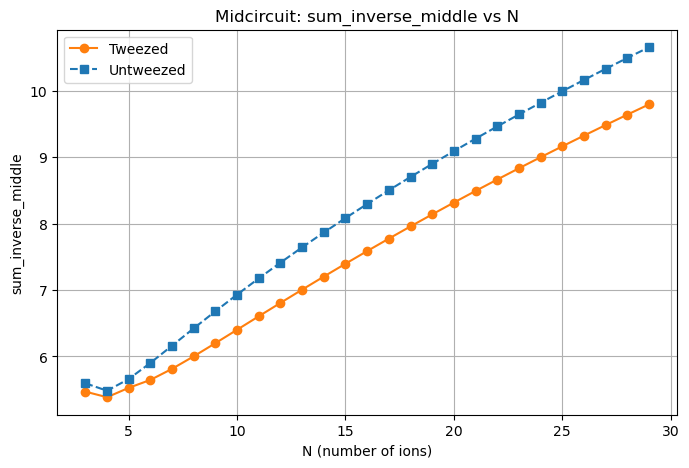

In [267]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

dfs = []
many_N = []

for N in range(3, 31):
    test_loop = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



# ...existing code...
dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 31):
    test_loop = midcircuit_modes_untweezed_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.scatter(Ns_t, vals_t, marker='o', color='C1', label='Tweezed')
if Ns_u.size:
    plt.scatter(Ns_u, vals_u, marker='s', color='C0', label='Untweezed')
plt.xlabel("N",fontsize = 12)
plt.ylabel(r"$\tau$", fontsize=12)
plt.title("One-ion-all-modes mapping",fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

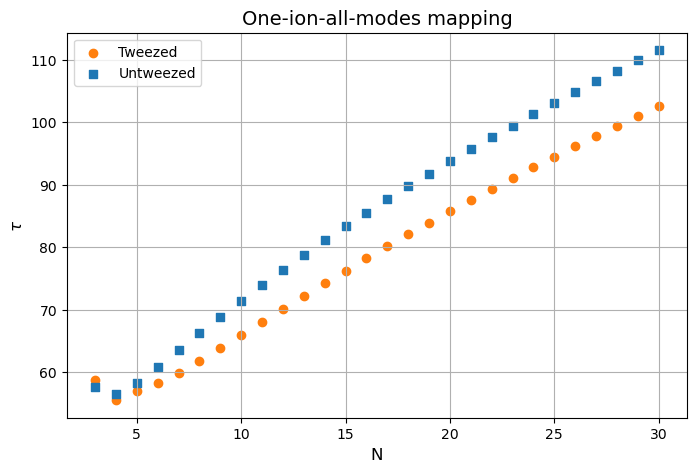

In [268]:
# ...existing code...
Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# print each plotted data point
if Ns_t.size:
    print("Tweezed points (N, sum_inverse_middle):")
    for n, v in zip(Ns_t, vals_t):
        print(f"  N={int(n)} -> {v}")
else:
    print("No Tweezed points")

if Ns_u.size:
    print("Untweezed points (N, sum_inverse_middle):")
    for n, v in zip(Ns_u, vals_u):
        print(f"  N={int(n)} -> {v}")
else:
    print("No Untweezed points")

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.scatter(Ns_t, vals_t, marker='o', color='C1', label='Tweezed')
if Ns_u.size:
    plt.scatter(Ns_u, vals_u, marker='s', color='C0', label='Untweezed')
plt.xlabel("N",fontsize = 12)
plt.ylabel(r"$\tau$", fontsize=12)
plt.title("One-ion-all-modes mapping",fontsize=14)
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

In [152]:
(102.59167079692004-111.5379006329242)/111.5379006329242


-0.08020798119059612

In [153]:
many_N

[(3,
     Tweezed Ion  Coolant Ion                                                     Mode couplings                                        inverse_mode_couplings  sum_inverse_middle
  0          1.0            0  [-0.05285882810862266, -0.06858435881036191, 0.04368580422859225]  [18.918315743683195, 14.580583931170576, 22.890731157594267]           56.389631),
 (4,
     Tweezed Ion  Coolant Ion                                                    Mode couplings                                        inverse_mode_couplings  sum_inverse_middle
  0          1.0            0  [0.04830526968334821, -0.0616606089377392, -0.05375113332401332]  [20.701675128929462, 16.217809347451205, 18.604258890170225]           55.523743
  1          2.0            3  [0.04830526968334764, 0.06166060893778588, -0.05375113332397893]   [20.701675128929708, 16.217809347438926, 18.60425889018213]           55.523743),
 (5,
     Tweezed Ion  Coolant Ion                                                       Mode 

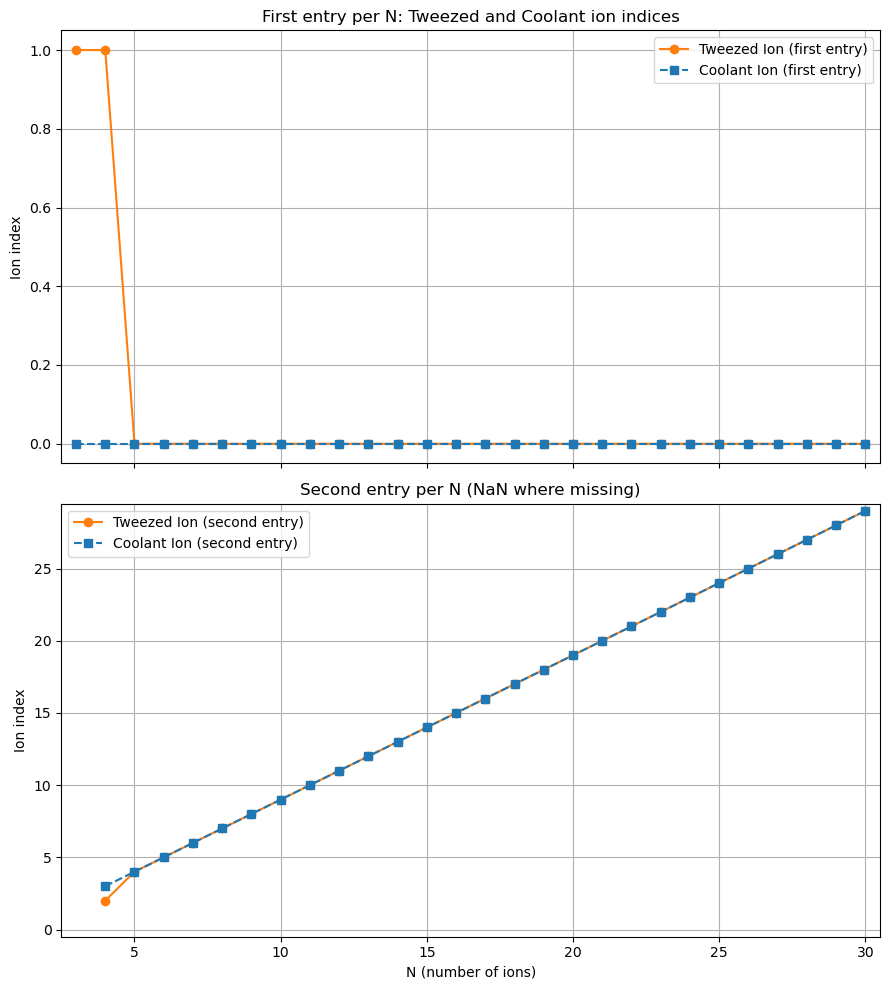

In [154]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _get_df_for_N(many, combined, N):
    if isinstance(many, list):
        for n, item in many:
            if n == N:
                if isinstance(item, pd.DataFrame):
                    return item.copy().reset_index(drop=True)
                return None
    if isinstance(combined, pd.DataFrame) and not combined.empty:
        tmp = combined[combined['N'] == N]
        if not tmp.empty:
            return tmp.copy().reset_index(drop=True)
    return None

many = globals().get('many_N')
combined = globals().get('combined_df')

if isinstance(many, list) and many:
    Ns = sorted({n for n, _ in many})
elif isinstance(combined, pd.DataFrame) and not combined.empty and 'N' in combined.columns:
    Ns = sorted(combined['N'].unique())
else:
    Ns = list(range(3, 30))

Ns = list(Ns)
first_t = []
first_c = []
second_t = []
second_c = []

for N in Ns:
    df = _get_df_for_N(many, combined, N)
    if df is None or df.empty:
        first_t.append(np.nan); first_c.append(np.nan)
        second_t.append(np.nan); second_c.append(np.nan)
        continue

    def safe_int(x):
        try:
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    # first entry (row 0)
    r0 = df.iloc[0]
    first_t.append(safe_int(r0.get('Tweezed Ion', np.nan)))
    first_c.append(safe_int(r0.get('Coolant Ion', np.nan)))

    # second entry (row 1) if available
    if len(df) > 1:
        r1 = df.iloc[1]
        second_t.append(safe_int(r1.get('Tweezed Ion', np.nan)))
        second_c.append(safe_int(r1.get('Coolant Ion', np.nan)))
    else:
        second_t.append(np.nan); second_c.append(np.nan)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(9,10), sharex=True)

axes[0].plot(Ns, first_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (first entry)')
axes[0].plot(Ns, first_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (first entry)')
axes[0].set_ylabel('Ion index')
axes[0].set_title('First entry per N: Tweezed and Coolant ion indices')
axes[0].grid(True)
axes[0].legend()

"""axes[1].plot(Ns, second_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (second entry)')
axes[1].plot(Ns, second_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (second entry)')
axes[1].set_xlabel('N (number of ions)')
axes[1].set_ylabel('Ion index')
axes[1].set_title('Second entry per N (NaN where missing)')
axes[1].grid(True)
axes[1].legend()"""

plt.xlim(min(Ns)-0.5, max(Ns)+0.5)
valid_vals = [v for v in (first_t + first_c + second_t + second_c) if not np.isnan(v)]
if valid_vals:
    plt.ylim(-0.5, max(valid_vals) + 0.5)

plt.tight_layout()
plt.show()


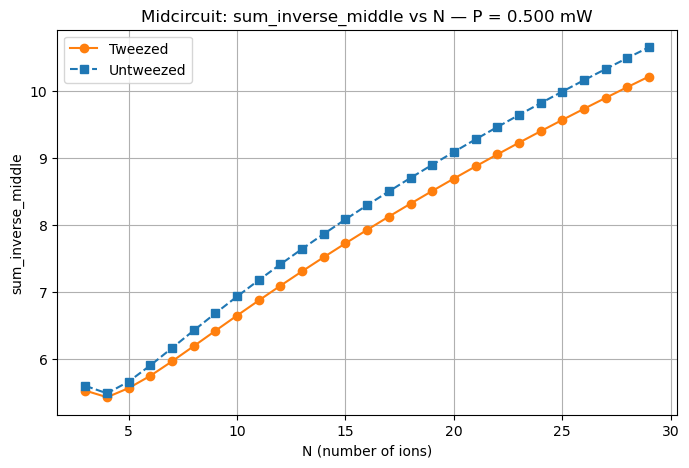

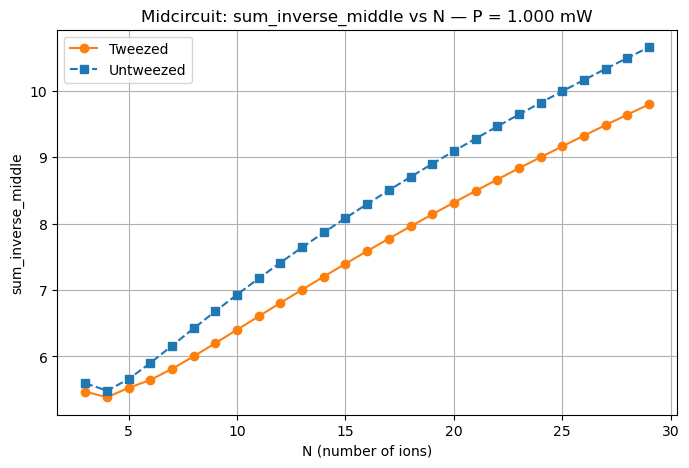

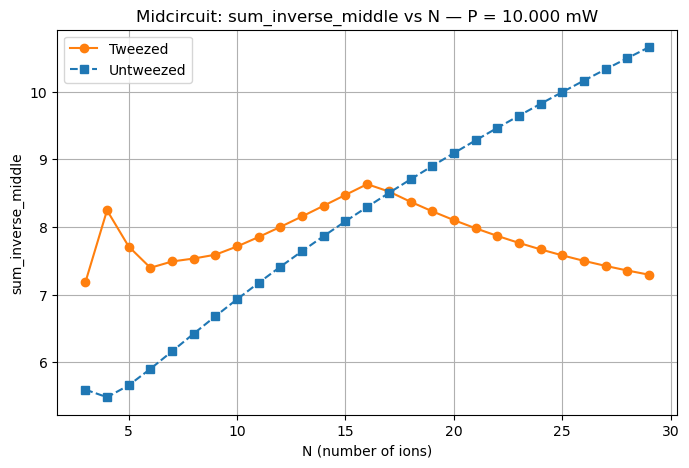

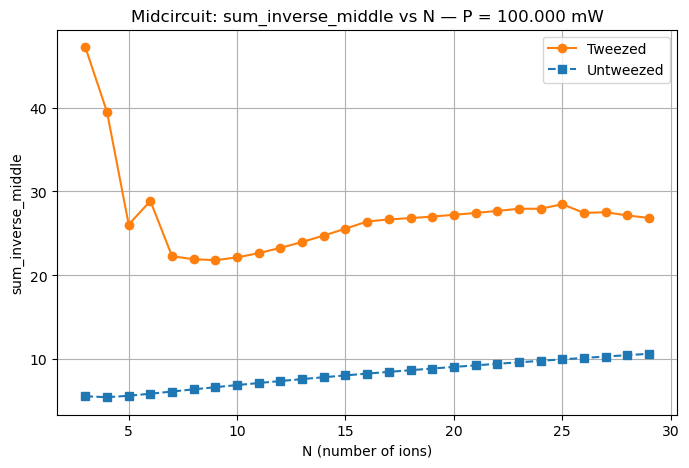

In [155]:
# ...existing code...
# loop over powers and plot per-power figure
import numpy as np
import matplotlib.pyplot as plt

# use the requested power list
power_values = [500e-6, 1e-3, 10e-3, 100e-3]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

for p in power_values:
    P_current = [p]    # functions expect a list-like P
    dfs = []
    dfs_untweezed = []
    many_N = []
    many_N_untweezed = []

    for N in range(3, 30):
        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N, f_rf_r, f_rf_a, P_current, w0
        )
        many_N.append((N, test_loop))
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N, f_rf_r, f_rf_a, P_current, w0
        )
        many_N_untweezed.append((N, test_loop_u))
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

    combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
    combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()


    Ns_t, vals_t = first_sum_by_N(combined_df)
    Ns_u, vals_u = first_sum_by_N(combined_untweezed)

    plt.figure(figsize=(8,5))
    if Ns_t.size:
        plt.plot(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
    if Ns_u.size:
        plt.plot(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
    plt.xlabel("N (number of ions)")
    plt.ylabel("sum_inverse_middle")
    # show power in mW instead of W
    plt.title(f"Midcircuit: sum_inverse_middle vs N — P = {p*1e3:.3f} mW")
    plt.grid(True)
    plt.legend()
    plt.show()
# ...existing code...

for N=10,N=20,N=30, what is the ratio of tweezed and untweezed as a function of power


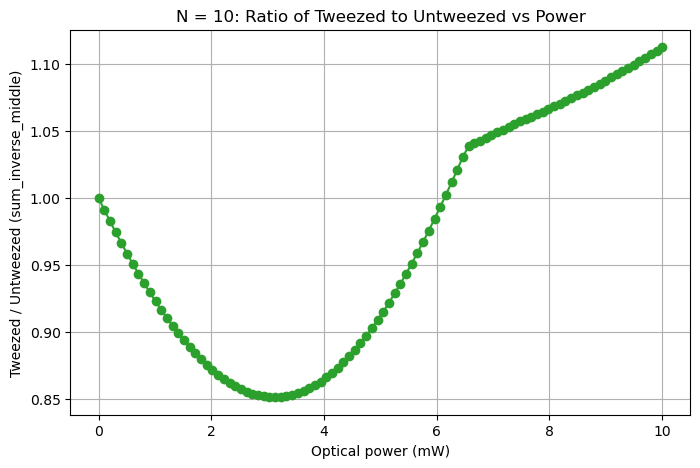

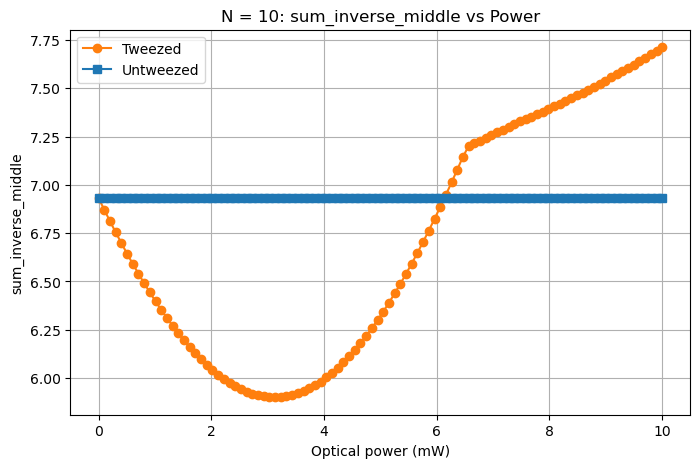

In [156]:
# ...existing code...
# fix N=10, sweep power and plot tweezed/untweezed ratio vs power
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6,10e-3,100)
N_fixed = 10

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = []
ratio_vals = []
t_vals = []
u_vals = []

for p in power_values:
    P_current = [p]
    dfs = []
    dfs_untweezed = []

    # only evaluate for fixed N
    test_loop = midcircuit_modes_test(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_fixed, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N_fixed)
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs.append(df)

    test_loop_u = midcircuit_modes_untweezed_test(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_fixed, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N_fixed)
        try:
            dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs_untweezed.append(dfu)

    combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
    combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

    _, vals_t = first_sum_by_N(combined_df)
    _, vals_u = first_sum_by_N(combined_untweezed)

    # pick first (only) entry if present
    val_t = vals_t[0] if vals_t.size else np.nan
    val_u = vals_u[0] if vals_u.size else np.nan

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.nan if np.isnan(val_t) and np.isnan(val_u) else (np.nan if val_u == 0 else (val_t / val_u))

    powers_mW.append(p * 1e3)
    ratio_vals.append(ratio)
    t_vals.append(val_t)
    u_vals.append(val_u)

# plot ratio vs power (x in mW)
plt.figure(figsize=(8,5))
plt.plot(powers_mW, ratio_vals, marker='o', linestyle='-', color='C2')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title(f"N = {N_fixed}: Ratio of Tweezed to Untweezed vs Power")
plt.grid(True)
plt.show()

# optional: also show raw values
plt.figure(figsize=(8,5))
plt.plot(powers_mW, t_vals, marker='o', label='Tweezed', color='C1')
plt.plot(powers_mW, u_vals, marker='s', label='Untweezed', color='C0')
plt.xlabel("Optical power (mW)")
plt.ylabel("sum_inverse_middle")
plt.title(f"N = {N_fixed}: sum_inverse_middle vs Power")
plt.legend()
plt.grid(True)
plt.show()
# ...existing code...

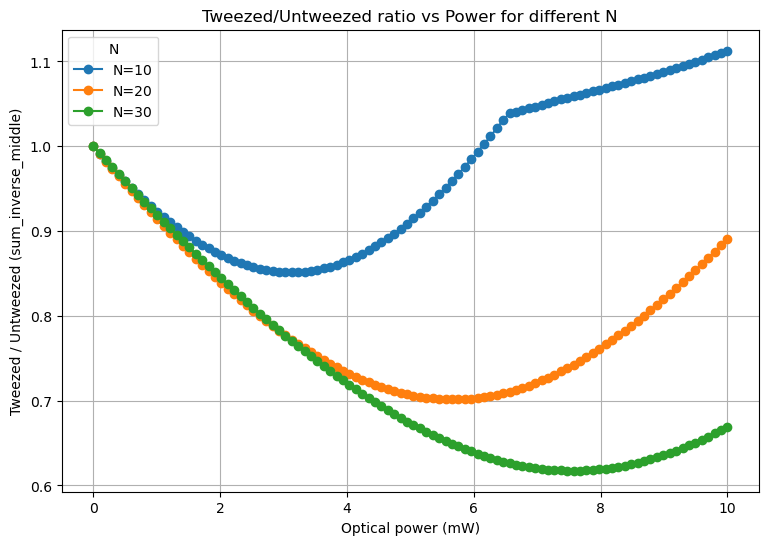

In [155]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 10e-3, 100)
Ns_to_plot = [10, 20, 30]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()


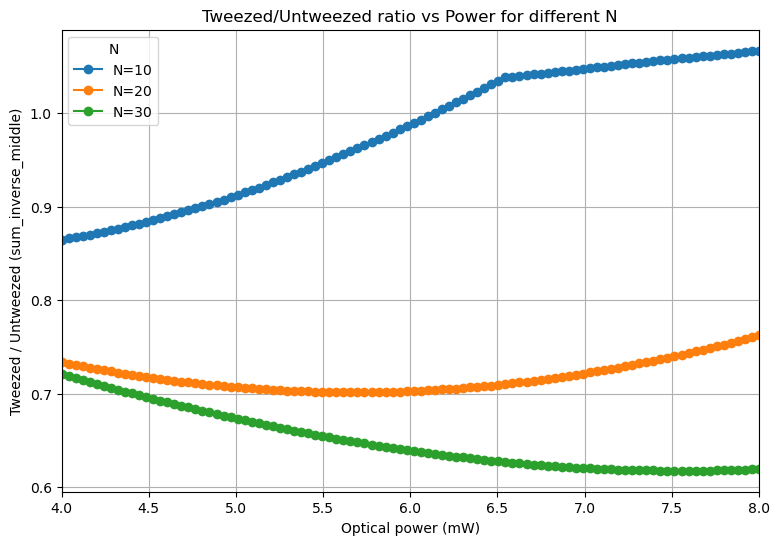

In [158]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values_zoomed_in = np.linspace(4e-3, 8e-3, 100)
Ns_to_plot = [10, 20, 30]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values_zoomed_in * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values_zoomed_in:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.xlim(min(powers_mW), max(powers_mW))
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()


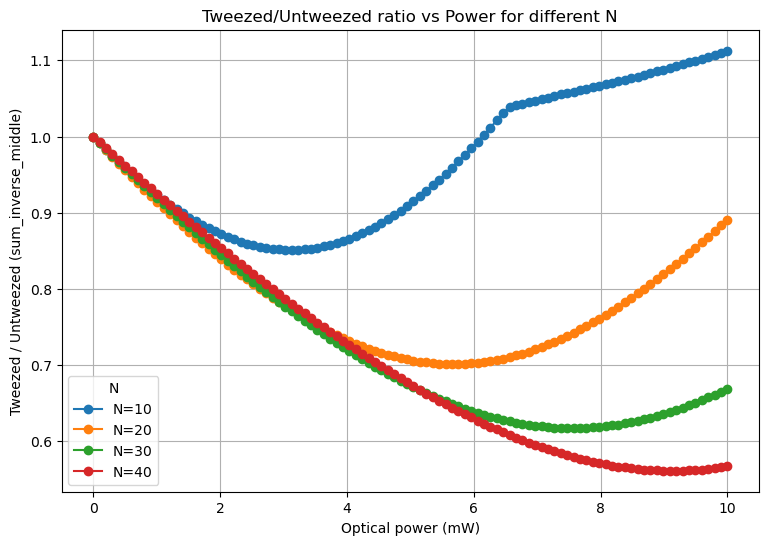

In [156]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 10e-3, 100)
Ns_to_plot = [10, 20, 30,40]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()


In [157]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 10e-3, 100)
Ns_to_plot = [10, 20, 30,40]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)




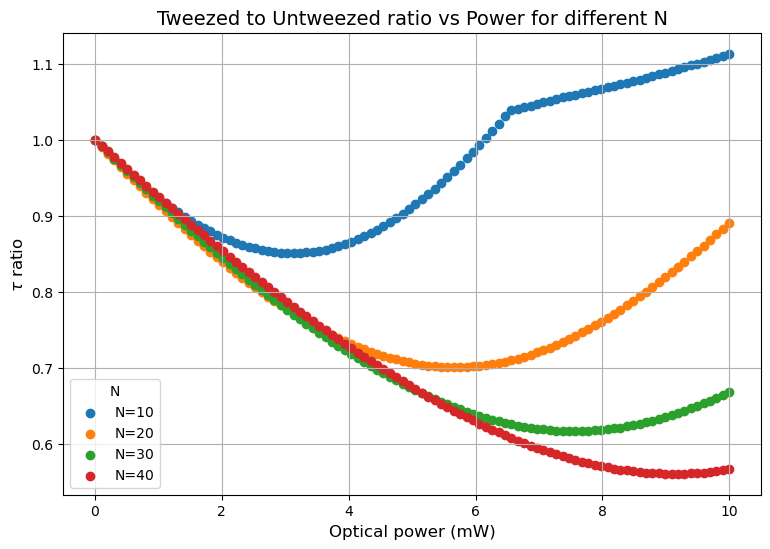

In [158]:
# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.scatter(powers_mW, ratio_vals[N_fixed], marker='o', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)",fontsize = 12)
plt.ylabel(r"$\tau$ ratio",fontsize = 12)
plt.title("Tweezed to Untweezed ratio vs Power for different N",fontsize = 14)
plt.grid(True)
plt.legend(title="N")
plt.show()

# Finding optimal powers for N=3 to N=31 and plotting midcircuit results


In [814]:
powersweep = np.linspace(1e-6, 0.1, 100)

# Initialize dictionaries to store results
sum_inverse_middle_per_N = {N: [] for N in range(3, 31)}
corresponding_power_per_N = {N: None for N in range(3, 31)}

for p in powersweep:
    for N in range(3, 31):
        # Call the function and get the output
        output = midcircuit_modes_test(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N, f_rf_r, f_rf_a, p, w0
        )

        # Extract "sum_inverse_middle" if the output is valid
        if isinstance(output, pd.DataFrame) and not output.empty:
            sum_inverse_middle = output["sum_inverse_middle"].iloc[0]
            sum_inverse_middle_per_N[N].append((p, sum_inverse_middle))

# Find the minimum "sum_inverse_middle" and corresponding power for each N
for N, values in sum_inverse_middle_per_N.items():
    if values:  # Ensure there are values to process
        min_power, min_sum_inverse = min(values, key=lambda x: x[1])
        corresponding_power_per_N[N] = min_power


In [815]:
# Display the power corresponding to the lowest "sum_inverse_middle" for each ion number
print("Ion Number (N) -> Power with Lowest sum_inverse_middle")
for N, power in corresponding_power_per_N.items():
    print(f"N={N}: Power={power:.6f} W" if power is not None else f"N={N}: No valid data")

Ion Number (N) -> Power with Lowest sum_inverse_middle
N=3: Power=0.000001 W
N=4: Power=0.002021 W
N=5: Power=0.001011 W
N=6: Power=0.002021 W
N=7: Power=0.002021 W
N=8: Power=0.002021 W
N=9: Power=0.003031 W
N=10: Power=0.003031 W
N=11: Power=0.003031 W
N=12: Power=0.004041 W
N=13: Power=0.004041 W
N=14: Power=0.004041 W
N=15: Power=0.004041 W
N=16: Power=0.005051 W
N=17: Power=0.005051 W
N=18: Power=0.005051 W
N=19: Power=0.005051 W
N=20: Power=0.006062 W
N=21: Power=0.006062 W
N=22: Power=0.006062 W
N=23: Power=0.006062 W
N=24: Power=0.006062 W
N=25: Power=0.007072 W
N=26: Power=0.007072 W
N=27: Power=0.007072 W
N=28: Power=0.007072 W
N=29: Power=0.007072 W
N=30: Power=0.007072 W


In [816]:
# Assuming `corresponding_power_per_N` contains the mapping of Ion Number (N) to Power with lowest sum_inverse_middle
# Extract the power values into a list
power_values_list = np.array(list(corresponding_power_per_N.values()))

# Display the list
print(power_values_list*1e3) #mW

[1.00000000e-03 2.02118182e+00 1.01109091e+00 2.02118182e+00
 2.02118182e+00 2.02118182e+00 3.03127273e+00 3.03127273e+00
 3.03127273e+00 4.04136364e+00 4.04136364e+00 4.04136364e+00
 4.04136364e+00 5.05145455e+00 5.05145455e+00 5.05145455e+00
 5.05145455e+00 6.06154545e+00 6.06154545e+00 6.06154545e+00
 6.06154545e+00 6.06154545e+00 7.07163636e+00 7.07163636e+00
 7.07163636e+00 7.07163636e+00 7.07163636e+00 7.07163636e+00]


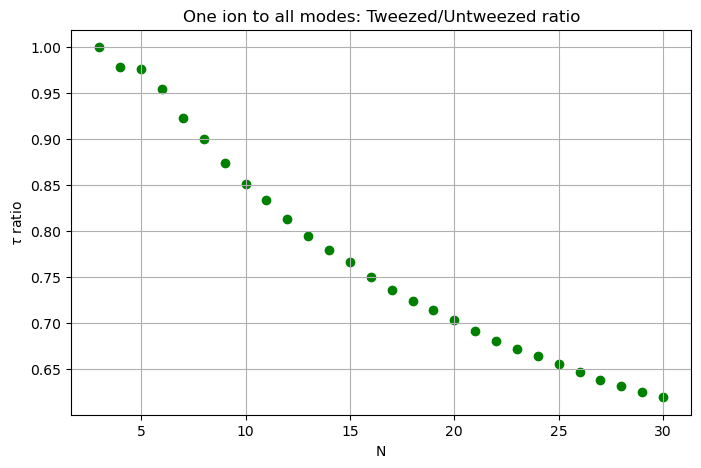

In [821]:
N_values = range(3, 31)  # Define the range of N values
P_values = power_values_list

# Ensure the lengths of N_values and P_values match
if len(P_values) < len(N_values):
    raise ValueError("The list P_values must have at least as many elements as N_values.")

dfs = []
many_N = []

# Iterate over N and the corresponding P value
for N, P in zip(N_values, P_values):
    P_current = [P]  # Wrap P in a list to match the expected input format
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P_current,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # Attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)

# Untweezed loop
dfs_untweezed = []
many_N_untweezed = []

for N, P in zip(N_values, P_values):
    P_current = [P]  # Wrap P in a list to match the expected input format
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P_current,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # Attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)

# Combine per-N DataFrames if not already done
combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

# Calculate the ratio of tweezed to untweezed
common_N = set(Ns_t).intersection(Ns_u)
ratios = {N: vals_t[np.where(Ns_t == N)[0][0]] / vals_u[np.where(Ns_u == N)[0][0]] for N in common_N}

# Sort the data by N for plotting
sorted_N = sorted(common_N)
sorted_ratios = [ratios[N] for N in sorted_N]

plt.figure(figsize=(8, 5))
#if Ns_t.size:
#    plt.scatter(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
#if Ns_u.size:
#    plt.scatter(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
plt.scatter(sorted_N, sorted_ratios, marker='o',  color='green')
plt.xlabel("N")
plt.ylabel(r"$\tau$ ratio")
plt.title("One ion to all modes: Tweezed/Untweezed ratio")
plt.grid(True)
plt.show()

## Checking what the results look like for N=3

In [862]:
coolant_3 = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        3,
        f_rf_r,
        f_rf_a,
        power_values_list[0],
        w0,
    )

In [863]:
coolant_3.keys()

Index(['Tweezed Ion', 'Coolant Ion', 'Mode couplings', 'inverse_mode_couplings', 'sum_inverse_middle'], dtype='object')

In [858]:
print(int(coolant_3['Coolant Ion']))

2


In [864]:
Coolant_ions = []
Tweezed_ions = []
for i in range(3,31):
    df = midcircuit_modes_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        i,
        f_rf_r,
        f_rf_a,
        power_values_list[i-3],
        w0,
    )
    Coolant_ions.append(int(df['Coolant Ion']))
    Tweezed_ions.append(int(df['Tweezed Ion']))


In [865]:
print(Coolant_ions)
print(Tweezed_ions)

[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [845]:
midcircuit_modes_untweezed_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        3,
        f_rf_r,
        f_rf_a,
        power_values_list[0],
        w0,
    )

,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,NaN,0,"[0.05595945091480255, -0.06858435881036137, 0.03963641089674457]","[17.87008241954492, 14.58058393117069, 25.229327715999943]",57.679994
1,NaN,2,"[0.055959450914800805, 0.06858435881036089, 0.03963641089674782]","[17.87008241954548, 14.580583931170793, 25.229327715997876]",57.679994


# Finding optimal powers across N

### N=7

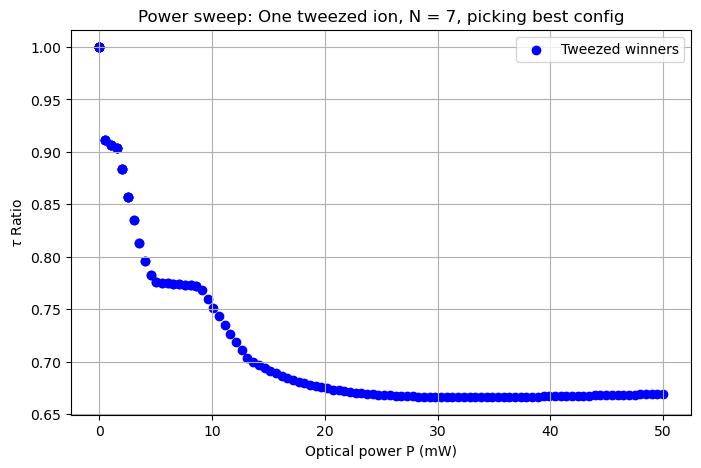

In [825]:
P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_7 = []
for Ni in range(7, 8):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_7.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_7: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_7:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_7[0], marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 7, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [826]:
P_opt_7_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_7[0])]*1e3
print(P_opt_7_mW )

32.828626262626265


## Checking optimal power for N = 2

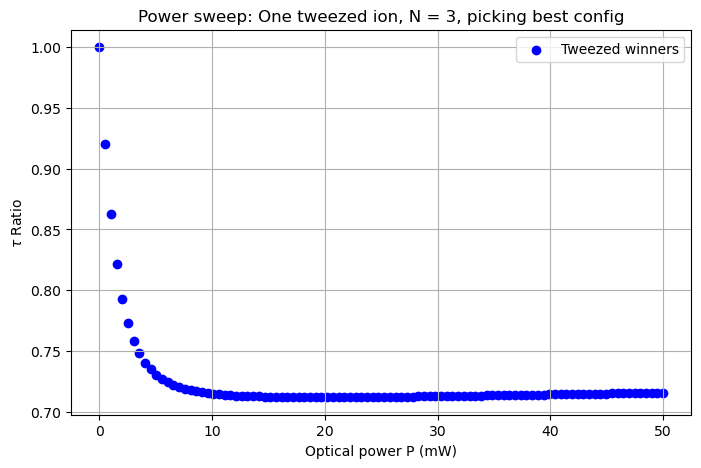

In [827]:
# add in N=2 back in 
P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_2= []
for Ni in range(2, 3):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_2.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_3: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_2:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_2[0], marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 3, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [828]:
P_opt_2_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_2[0])]*1e3
print(P_opt_2_mW )

19.697575757575763


## N=3

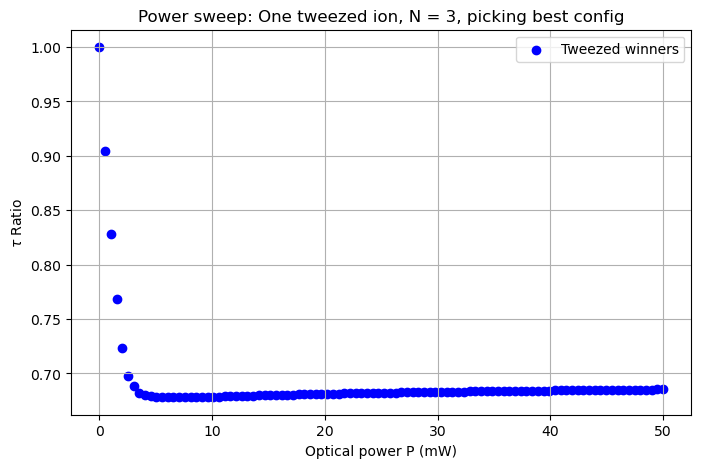

In [829]:
P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_3 = []
for Ni in range(3, 4):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_3.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_3: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_3:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_3[0], marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 3, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [830]:
P_opt_3_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_3[0])]*1e3
print(P_opt_3_mW )

7.0715656565656575


## N = 4

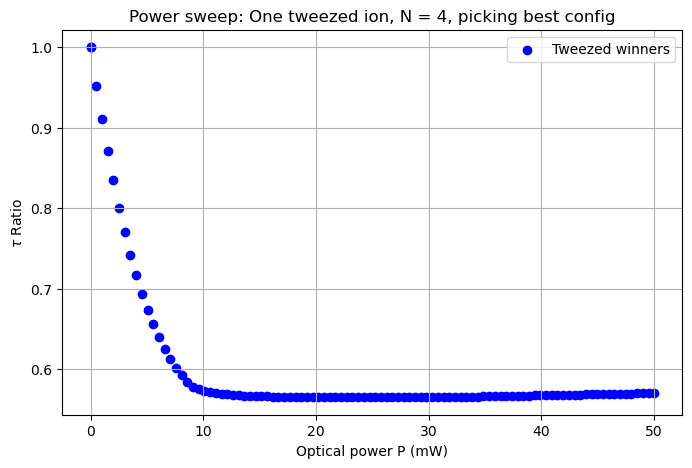

In [831]:
P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_4 = []
for Ni in range(4, 5):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_4.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_4: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_4:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_4[0], marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 4, picking best config")
plt.grid(True)
plt.legend()
plt.show()

In [832]:
P_opt_4_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_4[0])]*1e3 
print(P_opt_4_mW)

21.71773737373738


## N = 5

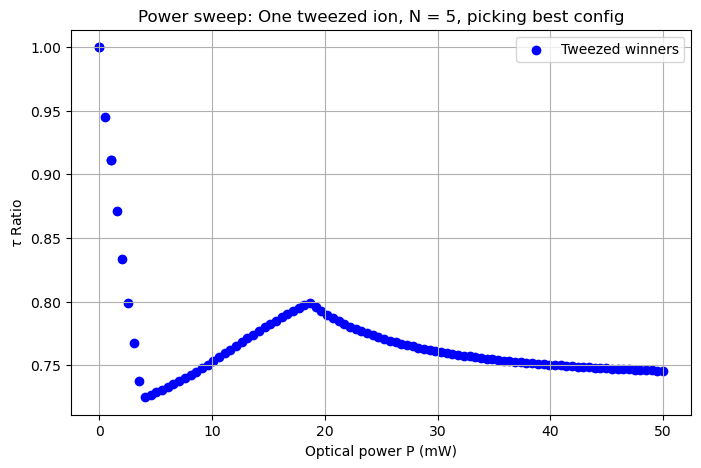

In [833]:

P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_5 = []
for Ni in range(5, 6):
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5.append((Ni, power_results))

# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_4: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_5:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_5[0], marker='o',color = 'blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()
#optimum power in mW


In [834]:
P_opt_5_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_5[0])]*1e3 
print(P_opt_5_mW)

4.041323232323233


## N = 6

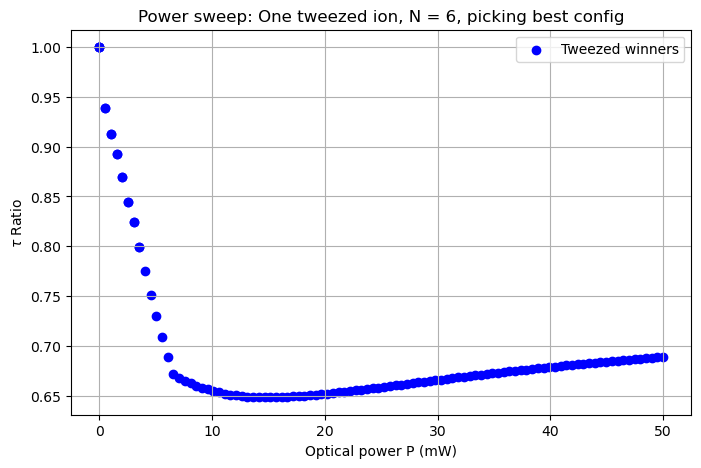

In [835]:

P_list = np.linspace(1e-6, 0.0500, 100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_6 = []
for Ni in range(6, 7):
    power_results = run_optimal_mode_selection_tweezed_power_sweep_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_6.append((Ni, power_results))

# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_4: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_6:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score, P_opt), (best_ion, best_mode))
        for winner in winners:
            if len(winner) != 2:
                continue
            outer, inner = winner
            # outer == (tweezed_ion, mapping, score, P_opt)
            if len(outer) != 4:
                continue
            tweezed_ion, mapping, score, _ = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed*1e3, (1/y_tweezed)/y_ref_6[0], marker='o',color = 'blue', label='Tweezed winners')
plt.xlabel("Optical power P (mW)")
plt.ylabel(r"$\tau$ Ratio")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config")
plt.grid(True)
plt.legend()
plt.show()
#optimum power in mW


In [836]:
P_opt_6_mW = x_tweezed[np.argmin((1/y_tweezed)/y_ref_6[0])]*1e3 
print(P_opt_6_mW)

15.152212121212122


In [837]:
P_opt_list = [P_opt_2_mW,P_opt_3_mW,P_opt_4_mW,P_opt_5_mW,P_opt_6_mW,P_opt_7_mW]
print(P_opt_list)

[19.697575757575763, 7.0715656565656575, 21.71773737373738, 4.041323232323233, 15.152212121212122, 32.828626262626265]


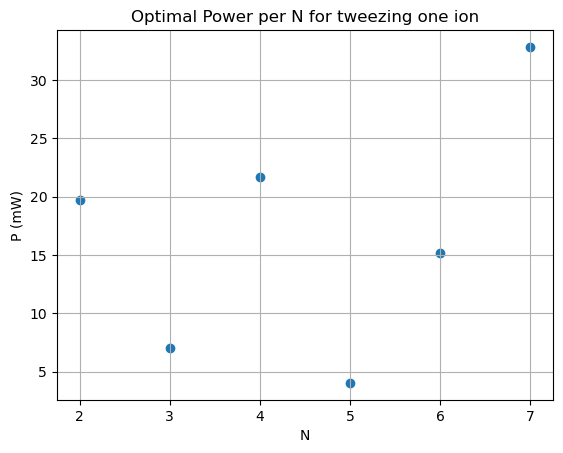

In [838]:
plt.scatter([2,3,4,5,6,7], P_opt_list, marker='o')
plt.xlabel("N")
plt.ylabel("P (mW)")
plt.grid(True)
plt.title("Optimal Power per N for tweezing one ion")
plt.show()

## Looking at the mode-vector contributions for N=5

In [869]:
P_opt_5_mW

4.041323232323233

In [874]:
results_power_sweep_5

[(5,
  [(1e-06,
    [((0, (0, 4, 2, 1, 3), 0.04335468251754514, 1e-06), (3, 1)),
     ((0, (0, 4, 2, 3, 1), 0.04335468251754514, 1e-06), (3, 3))]),
   (0.0005060404040404041,
    [((0, (0, 4, 2, 1, 3), 0.04588650871101701, 0.0005060404040404041),
      (1, 4))]),
   (0.0010110808080808081,
    [((1, (1, 0, 4, 3, 2), 0.04756756353521739, 0.0010110808080808081),
      (4, 2)),
     ((1, (1, 4, 0, 3, 2), 0.04756756353521739, 0.0010110808080808081),
      (4, 2))]),
   (0.0015161212121212124,
    [((1, (1, 4, 0, 3, 2), 0.049760827728738175, 0.0015161212121212124),
      (4, 2))]),
   (0.0020211616161616166,
    [((1, (1, 4, 0, 3, 2), 0.051991201031655235, 0.0020211616161616166),
      (4, 2))]),
   (0.0025262020202020206,
    [((1, (1, 4, 0, 3, 2), 0.05424203654165607, 0.0025262020202020206),
      (4, 2))]),
   (0.003031242424242425,
    [((1, (1, 4, 0, 3, 2), 0.0564956163705365, 0.003031242424242425),
      (4, 2))]),
   (0.003536282828282829,
    [((1, (1, 4, 0, 3, 2), -0.05873387164819

In [872]:
mode_vector_check_5 = tweezer_combos_full_radial_test(omega_tweezer,linewidths,omega_res,m,mode_calc_r,5,f_rf_r,f_rf_a,P_opt_5_mW,w0,max_tweezed=1)

In [877]:
mode_vector_check_5.iloc[2]

N                                                                                                                                               5
Tweezed ions                                                                                                                                 (1,)
P_per_tweezer (W)                                                                                                                        4.041323
Combined radial frequencies                      [6283185.307179586, 14219302.127737332, 6283185.307179586, 6283185.307179586, 6283185.307179586]
Mode0_freq                                                                                                                         2260980.971775
Mode0_eigvec                   [5.646086560093666e-05, 0.06445923069864222, 7.92098942076904e-05, 1.0004826738276208e-05, 2.6314663360765735e-06]
Mode1_freq                                                                                                                  

In [879]:
# access 'Mode2_eigvec' for the third row (index 2), tweezing 1, 
val = [
	mode_vector_check_5.iloc[2]["Mode0_eigvec"][1],
	mode_vector_check_5.iloc[2]["Mode1_eigvec"][4],
	mode_vector_check_5.iloc[2]["Mode2_eigvec"][0],
	mode_vector_check_5.iloc[2]["Mode3_eigvec"][2],
	mode_vector_check_5.iloc[2]["Mode4_eigvec"][3],
]
# round each element (round doesn't work on lists)
val_rounded = [round(float(x), 4) for x in val]
val_rounded

[0.0645, 0.0731, -0.0959, -0.059, 0.0654]

In [ ]:
#y_ref_5[0] is the untweezed reference value for N=5
(y_ref_5[0] - 1/np.min(np.abs(val)) ) / y_ref_5[0]

0.2658699125233048

## Redoing the N sweep sweep for optimal powers from N=2 to N=7

In [839]:

w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_optimal_power = []
for i, Ni in enumerate(range(2, 8)):
    # Use the corresponding P_opt for the current N
    P_opt = P_opt_list[i]*1e-3
    print(P_opt)
    winners = run_optimal_mode_selection_tweezed_only_test(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results_optimal_power.append((Ni, winners))


0.019697575757575764
0.007071565656565658
0.02171773737373738
0.004041323232323233
0.015152212121212122
0.03282862626262627


In [840]:
results_optimal_power

[(2, [((0, (0, 1), 0.09624126522590519, 0.019697575757575764), (1, 1))]),
 (3, [((0, (0, 2, 1), -0.08251491336286615, 0.007071565656565658), (0, 0))]),
 (4, [((1, (1, 3, 0, 2), 0.08577333357960697, 0.02171773737373738), (2, 0))]),
 (5,
  [((1, (1, 4, 0, 3, 2), -0.059787040082443864, 0.004041323232323233),
    (4, 2))]),
 (6,
  [((2, (2, 5, 0, 4, 1, 3), 0.06102827283143321, 0.015152212121212122),
    (2, 0))]),
 (7,
  [((2, (2, 6, 0, 4, 1, 5, 3), -0.05500904243387041, 0.03282862626262627),
    (0, 2))])]

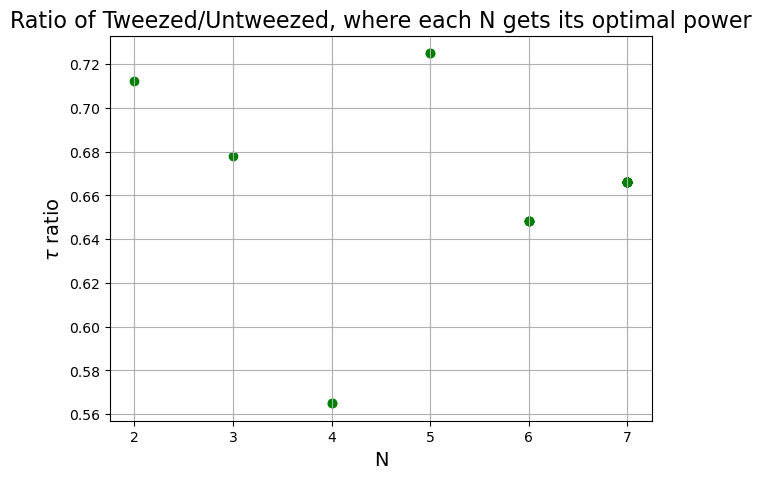

In [841]:
import numpy as np
import matplotlib.pyplot as plt

def _extract_score_from_win(win):
    """Return numeric score from a winner entry or None if not found."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from a winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]

# Tweezed winners only
x_tweezed = []
y_tweezed = []

for N_val, winners in results_optimal_power:
    if not winners:
        continue
    for win in winners:
        tweezed_ion = _extract_tweezed_ion(win)
        if tweezed_ion is None:
            continue   # skip untweezed
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)

# Calculate the ratio (1/y_tweezed) / (1/y_untweezed) = y_untweezed / y_tweezed per N
Ns = np.unique(np.concatenate((x_tweezed, x_untweezed)))
ratios = []

for N in Ns:
    tweezed_scores = y_tweezed[x_tweezed == N]
    untweezed_scores = y_untweezed[x_untweezed == N]
    if len(tweezed_scores) == 0 or len(untweezed_scores) == 0:  # Avoid division by zero
        continue
    # Compute the ratio for each untweezed score to each tweezed score
    for tweezed_score in tweezed_scores:
        for untweezed_score in untweezed_scores:
            ratios.append((N, untweezed_score / tweezed_score))

# Separate the ratios into x and y for plotting
x_ratios = np.array([r[0] for r in ratios])
y_ratios = np.array([r[1] for r in ratios])

# Plot the ratios
plt.figure(figsize=(7, 5))
plt.scatter(x_ratios, y_ratios, color='green')
plt.xlabel('N',fontsize = 14)
plt.ylabel(r'$\tau$ ratio',fontsize = 14)
plt.title(r'Ratio of Tweezed/Untweezed, where each N gets its optimal power',fontsize = 16)
plt.grid(True)
plt.show()

In [842]:
y_ratios

array([0.71212749, 0.67817378, 0.56500434, 0.56500434, 0.72500669,
       0.72500669, 0.64837665, 0.64837665, 0.64837665, 0.64837665,
       0.66596433, 0.66596433, 0.66596433, 0.66596433, 0.66596433,
       0.66596433, 0.66596433, 0.66596433, 0.66596433, 0.66596433,
       0.66596433, 0.66596433, 0.66596433, 0.66596433, 0.66596433,
       0.66596433])

In [843]:
import numpy as np

# print y_ratios without duplicates, preserving original order

y_ratios_P_opt = np.array(list(dict.fromkeys(y_ratios.tolist())))
print(y_ratios_P_opt)

[0.71212749 0.67817378 0.56500434 0.72500669 0.64837665 0.66596433]


In [844]:
print(y_ratios_unique_P_4_mW[5])
print(y_ratios_P_opt[5])

0.796722391341253
0.6659643275234249
